# 

# 설정 세팅

In [1]:
# "as name" indicates the name we will use to refer to this library
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
# we will only import certain module from those libraries
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from random import randrange
from datetime import datetime
import math
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.simplefilter(action='ignore', category=FutureWarning)
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


2026-03-17 16:19:09.972776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 16:19:10.560231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 16:19:12.100577: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

## 파일 불러오기

In [3]:
HOME = os.getcwd()
train_path = os.path.join(HOME, "data", "raw_data", "train")
train_path_list = []
for path in os.listdir(train_path):
    train_path_list.append(os.path.join(train_path, path))

In [4]:
test_path_list = []
test_path = os.path.join(HOME, "data", "raw_data", "test")
for path in os.listdir(test_path):
    test_path_list.append(os.path.join(test_path, path))

- train_list_path에 경로를 저장해두고 사용
- chg, dchg는 각각 충전과 방전을 의미하며, 충방전 데이터를 전처리해보자.

- df는 짧게 확인하는 코드
- 데이터의 columns는 동일하기 때문에, 확인하는 코드는 반드시 필요하다.

In [5]:
df = pd.read_csv(train_path_list[0])
display(df.head(), df.tail())
display(df.columns[0:30])

,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
0,2020-08-04,15:51:49,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
1,2020-08-04,15:51:50,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.9,31.8,32.0,31.6,31.7
2,2020-08-04,15:51:51,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.9,31.8,32.0,31.6,31.7
3,2020-08-04,15:51:52,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7
4,2020-08-04,15:51:53,1000,641.3,0.0,33.43,34.29,33.84,33,34,...,31.6,31.7,31.8,31.5,31.7,31.8,31.8,32.0,31.6,31.7


,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
6004,2020-08-04,17:33:01,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6005,2020-08-04,17:33:02,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6006,2020-08-04,17:33:03,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6007,2020-08-04,17:33:04,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.3
6008,2020-08-04,17:33:05,1000,714.5,0.0,89.6,90.46,90.01,100,100,...,35.9,36.3,36.0,35.6,36.2,35.9,36.3,36.0,35.9,35.4


Index(['Date', 'Time', 'SerialNumber', 'Voltage', 'Current', 'RSOCmin',
       'RSOCmax', 'RSOCavg', 'USOCmin', 'USOCmax', 'USOCavg', 'SOH', 'Power',
       'ChgPmax', 'DchgPmax', 'ChgImax', 'DchgImax', 'Vmin', 'Vmax', 'DV',
       'Tmin', 'Tmax', 'Tavg', 'M01CV01', 'M01CV02', 'M01CV03', 'M01CV04',
       'M01CV05', 'M01CV06', 'M01CV07'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6009 entries, 0 to 6008
Columns: 231 entries, Date to M16T02
dtypes: float64(219), int64(10), object(2)
memory usage: 10.6+ MB


In [7]:
df.shape

(6009, 231)

In [8]:
df.dtypes

Date             object
Time             object
SerialNumber      int64
Voltage         float64
Current         float64
                 ...   
M14T02          float64
M15T01          float64
M15T02          float64
M16T01          float64
M16T02          float64
Length: 231, dtype: object

- 시계열과 관련된 column 을 확인해본 결과
  - 총 231개의 column이 존재한다.
  - 이중 Date, Time이라는 시계열 데이터가 존재한다.
  - Date는 동일할 것이기 때문에, 이 필요없는 데이터로 보인다.
- 먼저 값이 변하지 않는 동일한 데이터가 있는지 먼저 확인해보자.

In [9]:
df.nunique(axis = 0)

Date               1
Time            6009
SerialNumber       1
Voltage          712
Current          286
                ... 
M14T02            46
M15T01            50
M15T02            43
M16T01            48
M16T02            40
Length: 231, dtype: int64

In [10]:
# 모든 수가 동일한 column
set(df.loc[:,df.nunique(axis = 0) == 1].columns)

{'Date', 'DchgImax', 'SOH', 'SerialNumber'}

- 다른 것들을 불러와서 그 column들도 동일한지 한번 확인해본다.

In [11]:
# column에서 모든 값이 동일한 경우
# 그 중 너무 많은 동일한 경우를 가지고 있을 때
def check_columns_one(train_path_list, length=4):
    temp = []
    count = 0
    for path in train_path_list:
        df = pd.read_csv(path)
        df = set(df.loc[:, df.nunique(axis = 0) == 1].columns)
        # 합집합으로 temp에 원본을 보관
        print(f"{os.path.basename(path)}: {df}")
        if len(df) > length :temp.append(os.path.basename(path))
    return temp

In [12]:
many_data_list = check_columns_one(train_path_list)

1000_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1000_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1001_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1001_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1002_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1002_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1003_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1003_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1004_chg.csv: {'SOH', 'SerialNumber', 'Date'}
1004_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1005_chg.csv: {'SOH', 'SerialNumber', 'Date'}
1005_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1006_chg.csv: {'SOH', 'SerialNumber', 'Date'}
1006_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1007_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1007_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1008_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1008_dchg.csv: {'SOH', 'SerialNumber', 'Date'}
1009_chg.csv: {'SOH', 'DchgImax', 'SerialNumber', 'Date'}
1009_dchg.csv: {'SOH', 'SerialNum

In [13]:
many_data_list

['1013_dchg.csv',
 '1014_dchg.csv',
 '1015_dchg.csv',
 '1016_dchg.csv',
 '1017_chg.csv',
 '1017_dchg.csv',
 '1019_chg.csv',
 '1030_chg.csv',
 '1032_chg.csv',
 '1035_chg.csv',
 '1036_chg.csv',
 '1038_chg.csv',
 '1043_chg.csv']

In [14]:
# 결측치를 가지고 있는 데이터를 찾아내는 함수
def find_nan(train_path_list):
    temp = []
    for path in train_path_list:
        df = pd.read_csv(path)
        if df.isna().values.any():
            temp.append(os.path.basename(path))
    return temp

In [15]:
have_nan_data = find_nan(train_path_list)

In [16]:
have_nan_data

['1012_dchg.csv',
 '1013_chg.csv',
 '1025_chg.csv',
 '1026_chg.csv',
 '1033_dchg.csv',
 '1050_chg.csv']

- 데이터를 전처리할 때, 위 파일들의 경우에는 이런 결측치 처리가 반드시 필요하다.
  - 결측치 처리 : ['1012_dchg.csv', '1013_chg.csv', '1025_chg.csv', '1026_chg.csv', '1033_dchg.csv', '1050_chg.csv']
  - 단일값 처리 : ['1013_dchg.csv', '1014_dchg.csv', '1015_dchg.csv', '1016_dchg.csv', '1017_chg.csv', '1017_dchg.csv', '1019_chg.csv', '1030_chg.csv', '1032_chg.csv', '1035_chg.csv', '1036_chg.csv', '1038_chg.csv', '1043_chg.csv']

# 데이터 모두 불러오기


In [17]:
def make_df_list(file_path_list):
    df_list = []
    for path in file_path_list:
        df = pd.read_csv(path)
        df_list.append(df)
    return df_list

In [18]:
train_list = make_df_list(train_path_list)
test_list = make_df_list(test_path_list)

In [19]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
import json
import os

def plot_comparison(
    df_list,
    df_names=None,
    downsample=10,
    num_columns=4,
    output_file="comparison.html",
):
    if not df_list:
        return print("데이터프레임 리스트가 비어있습니다.")

    num_df = len(df_list)
    if df_names is None:
        df_names = [f"Dataset {i+1}" for i in range(num_df)]
    elif isinstance(df_names, str):
        df_names = [f"{df_names}_{i+1}" for i in range(num_df)]
    elif len(df_names) < num_df:
        df_names = list(df_names) + [f"Dataset {i+1}" for i in range(len(df_names), num_df)]

    cols = df_list[0].columns[23:].tolist()
    total_cols = len(cols)
    num_rows = math.ceil(total_cols / num_columns)
    v_spacing = min(0.06, 0.85 / max(num_rows, 1))

    # ── 파일별 figure JSON 생성 ──────────────────────────────────
    all_figs_json = []

    for df_idx, df in enumerate(df_list):
        fig = make_subplots(
            rows=num_rows, cols=num_columns,
            subplot_titles=cols,
            vertical_spacing=v_spacing,
            horizontal_spacing=0.05,
        )

        df_s = df.iloc[::downsample]
        x = df_s['Time'].values if 'Time' in df_s.columns else df_s.index.values

        for i, col_name in enumerate(cols):
            curr_row = (i // num_columns) + 1
            curr_col = (i % num_columns) + 1

            if col_name not in df_s.columns:
                continue

            fig.add_trace(go.Scatter(
                x=x,
                y=df_s[col_name].values,
                mode='lines',
                line=dict(color='#4C9BE8', width=1.2),
                showlegend=False,
                hovertemplate='%{x}<br>%{y:.3f}<extra></extra>',
            ), row=curr_row, col=curr_col)

        fig.update_layout(
            height=max(400, num_rows * 200),
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
            font=dict(family='IBM Plex Sans, sans-serif', color='#2d3047'),
            hovermode='x unified',
            showlegend=False,
            margin=dict(t=50, b=30, l=40, r=20),
        )
        fig.update_xaxes(showgrid=True, gridcolor='#e8eaf0', zeroline=False)
        fig.update_yaxes(showgrid=True, gridcolor='#e8eaf0', zeroline=False, matches=None)
        fig.update_annotations(font_size=9, font_color='#4a4e6a')

        all_figs_json.append(fig.to_json())

    # ── HTML 생성 ────────────────────────────────────────────────
    html = f"""<!DOCTYPE html>
<html lang="ko">
<head>
<meta charset="UTF-8">
<title>파일별 전압 모니터링</title>
<link href="https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@300;400;600&family=IBM+Plex+Mono:wght@400;600&display=swap" rel="stylesheet">
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: 'IBM Plex Sans', sans-serif;
    background: #f4f6fb;
    color: #2d3047;
    min-height: 100vh;
  }}
  header {{
    background: #1a1a2e;
    color: #fff;
    padding: 16px 32px;
    display: flex;
    align-items: center;
    justify-content: space-between;
    position: sticky;
    top: 0;
    z-index: 100;
    box-shadow: 0 2px 16px rgba(0,0,0,.3);
  }}
  .title-block h1 {{ font-size: 1rem; font-weight: 600; letter-spacing: .04em; }}
  .title-block span {{
    font-family: 'IBM Plex Mono', monospace;
    font-size: .7rem;
    color: #8899cc;
    display: block;
    margin-top: 3px;
  }}
  .controls {{
    display: flex;
    align-items: center;
    gap: 10px;
  }}
  .btn {{
    background: rgba(255,255,255,.1);
    border: 1px solid rgba(255,255,255,.2);
    color: #fff;
    padding: 7px 16px;
    border-radius: 6px;
    font-size: .82rem;
    cursor: pointer;
    font-family: 'IBM Plex Sans', sans-serif;
    transition: background .15s;
    white-space: nowrap;
  }}
  .btn:hover {{ background: rgba(255,255,255,.22); }}
  .btn:disabled {{ opacity: .3; cursor: default; }}
  .page-info {{
    font-family: 'IBM Plex Mono', monospace;
    font-size: .8rem;
    color: #aabbdd;
    min-width: 80px;
    text-align: center;
  }}
  .jump-wrap {{
    display: flex;
    align-items: center;
    gap: 6px;
  }}
  .jump-wrap label {{ font-size: .75rem; color: #8899cc; font-family: 'IBM Plex Mono', monospace; }}
  .jump-input {{
    width: 50px;
    padding: 6px 8px;
    border-radius: 6px;
    border: 1px solid rgba(255,255,255,.2);
    background: rgba(255,255,255,.08);
    color: #fff;
    font-family: 'IBM Plex Mono', monospace;
    font-size: .8rem;
    text-align: center;
  }}
  .jump-input:focus {{ outline: none; border-color: #4C9BE8; }}
  .progress-bar {{ height: 3px; background: #e0e4f0; }}
  .progress-fill {{
    height: 100%;
    background: linear-gradient(90deg, #4C9BE8, #4CE8A0);
    transition: width .25s ease;
  }}
  main {{
    padding: 20px 24px 48px;
    max-width: 1600px;
    margin: 0 auto;
  }}
  .file-label {{
    display: inline-block;
    margin-bottom: 14px;
    background: #fff;
    border: 1px solid #e0e4f0;
    border-left: 4px solid #4C9BE8;
    border-radius: 6px;
    padding: 8px 18px;
    font-family: 'IBM Plex Mono', monospace;
    font-size: .82rem;
    color: #2d3047;
    box-shadow: 0 1px 6px rgba(44,48,80,.06);
  }}
  #chart-wrap {{
    background: #fff;
    border-radius: 12px;
    border: 1px solid #e0e4f0;
    overflow: hidden;
    box-shadow: 0 2px 20px rgba(44,48,80,.07);
  }}
  #plot {{ width: 100%; }}
  .loader {{
    display: none;
    position: fixed;
    inset: 0;
    background: rgba(244,246,251,.75);
    z-index: 200;
    align-items: center;
    justify-content: center;
    flex-direction: column;
    gap: 12px;
  }}
  .loader.active {{ display: flex; }}
  .spinner {{
    width: 34px; height: 34px;
    border: 3px solid #e0e4f0;
    border-top-color: #4C9BE8;
    border-radius: 50%;
    animation: spin .7s linear infinite;
  }}
  @keyframes spin {{ to {{ transform: rotate(360deg); }} }}
  .loader-text {{ font-size: .82rem; color: #4a4e6a; font-family: 'IBM Plex Mono', monospace; }}
</style>
</head>
<body>

<header>
  <div class="title-block">
    <h1>파일별 전압 모니터링</h1>
    <span>전체 {num_df}개 파일 · {total_cols}개 채널 · 다운샘플 1/{downsample}</span>
  </div>
  <div class="controls">
    <button class="btn" id="btnFirst" onclick="goPage(0)">«</button>
    <button class="btn" id="btnPrev"  onclick="goPage(cur-1)">‹ 이전</button>
    <div class="page-info" id="pageInfo"></div>
    <button class="btn" id="btnNext"  onclick="goPage(cur+1)">다음 ›</button>
    <button class="btn" id="btnLast"  onclick="goPage(total-1)">»</button>
    <div class="jump-wrap">
      <label>이동</label>
      <input class="jump-input" id="jumpInput" type="number" min="1" max="{num_df}"
             placeholder="1" onkeydown="if(event.key==='Enter') jumpPage()">
    </div>
  </div>
</header>

<div class="progress-bar">
  <div class="progress-fill" id="progressFill"></div>
</div>

<main>
  <div class="file-label" id="fileLabel"></div>
  <div id="chart-wrap">
    <div id="plot"></div>
  </div>
</main>

<div class="loader" id="loader">
  <div class="spinner"></div>
  <div class="loader-text" id="loaderText">렌더링 중...</div>
</div>

<script>
const FIGS  = {json.dumps(all_figs_json)};
const NAMES = {json.dumps(df_names)};
const total = FIGS.length;
let cur = 0;
let inited = false;

function updateUI() {{
  document.getElementById('pageInfo').textContent  = `${{cur+1}} / ${{total}}`;
  document.getElementById('fileLabel').textContent = NAMES[cur];
  document.getElementById('progressFill').style.width = ((cur+1)/total*100) + '%';
  document.getElementById('btnFirst').disabled = cur === 0;
  document.getElementById('btnPrev').disabled  = cur === 0;
  document.getElementById('btnNext').disabled  = cur === total-1;
  document.getElementById('btnLast').disabled  = cur === total-1;
}}

function renderPage(idx) {{
  const loader = document.getElementById('loader');
  document.getElementById('loaderText').textContent = `렌더링 중... (${{NAMES[idx]}})`;
  loader.classList.add('active');
  setTimeout(() => {{
    const fig = JSON.parse(FIGS[idx]);
    const el  = document.getElementById('plot');
    if (!inited) {{
      Plotly.newPlot(el, fig.data, fig.layout, {{
        responsive: true,
        displayModeBar: true,
        modeBarButtonsToRemove: ['select2d','lasso2d'],
      }});
      inited = true;
    }} else {{
      Plotly.react(el, fig.data, fig.layout);
    }}
    loader.classList.remove('active');
    updateUI();
  }}, 30);
}}

function goPage(p) {{
  if (p < 0 || p >= total) return;
  cur = p;
  renderPage(cur);
  document.getElementById('jumpInput').value = '';
}}

function jumpPage() {{
  const v = parseInt(document.getElementById('jumpInput').value);
  if (!isNaN(v) && v >= 1 && v <= total) goPage(v-1);
}}

document.addEventListener('keydown', e => {{
  if (e.target.tagName === 'INPUT') return;
  if (e.key === 'ArrowRight') goPage(cur+1);
  if (e.key === 'ArrowLeft')  goPage(cur-1);
}});

renderPage(0);
</script>
</body>
</html>"""

    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html)

    size_mb = os.path.getsize(output_file) / 1024 / 1024
    print(f"✅ 저장 완료: {output_file} ({size_mb:.1f} MB)")
    print(f"   {num_df}개 파일 · 파일당 {total_cols}개 채널")
    print(f"   브라우저에서 열고 ← → 키 또는 버튼으로 파일 이동")

In [20]:
train_name_list = [os.path.basename(f) for f in train_path_list]
test_name_list = [os.path.basename(f) for f in test_path_list]

In [21]:
# 시각화 자료
# plot_comparison(train_list, df_names = train_name_list, output_file = "train_data_comparison.html")
# plot_comparison(test_list, df_names = test_name_list, output_file = "test_data_comparison.html")

#### test 파일의 파형을 확인해본 결과, 테스트 한 파일들은 중간에 갑자기 튀어오르는 경향이 있고, 특정 파일들은 중간에 오르는 기울기가 꺾이는 현상이 발생한다. 즉, 특정 구간별로 오류가 있는것 이 확인이 가능한데... 문제는 이 부분부분을 전부 가능한가? 생각이 든단 말이지... 
1. 가이드북 방식 : PCA 방식을 유지하기
2. 배터리 팩의 각 셀별로 되어있지만, 이러한 셀들 전체를 시계열 학습시키는 방향으로도 가능하지 않을까? - 예시 : M01V1과 M01V2 데이터를 각자 학습시키고, 여러개의 데이터에 전체 적용하여 레이블 중 잘못된 검출 부분이 있는지 학습 시키는 것이다. -> 다만 틀린 데이터가 없어서... 이게 될지는 모르겠다.

# 데이터셋 정보 흝어보기

* **기본 정보 및 상태 (Basic Info)**

    * **Date(날짜)** : 데이터가 기록된 년-월-일 정보입니다.
    * **Time(시간)** : 데이터가 기록된 시-분-초 정보입니다.
    * **SerialNumber(일련번호)** : 배터리 팩 또는 모듈을 식별하는 고유 번호입니다.
    * **SOH(배터리 건강 상태)** : State of Health. 신품 대비 현재 배터리의 용량이나 성능이 어느 정도 남아있는지를 나타내는 백분율(%)입니다.

* **전기적 특성 (Electrical Specs)**

    * **Voltage(전압)** : 배터리 팩의 전체 출력 전압(V)입니다.
    * **Current(전류)** : 배터리에 흐르는 전류(A)입니다. 충전 시(+)와 방전 시(-)의 부호가 다르게 기록됩니다.
    * **Power(전력)** : 전압과 전류를 곱한 값($P = V \times I$)으로, 현재 소비하거나 충전 중인 에너지의 양(W)입니다.

* **충전 상태 (SOC - State of Charge)**
    * **RSOCmin / max / avg(실제 충전율 최솟값/최댓값/평균값)** : Relative SOC. 배터리 셀들 간의 편차를 고려한 실제 물리적인 충전 상태의 통계치입니다.
    * **USOCmin / max / avg(사용자 표시 충전율 최솟값/최댓값/평균값)** : User SOC. 실제 배터리 보호 구간을 제외하고 사용자에게 화면으로 보여주는 가공된 충전 상태입니다.

* **입출력 제한 (Limits)**

    * **ChgPmax(최대 충전 가능 전력)** : 현재 배터리 상태에서 받아들일 수 있는 최대 충전 전력(W) 제한치입니다.
    * **DchgPmax(최대 방전 가능 전력)** : 현재 배터리에서 뽑아 쓸 수 있는 최대 방전 전력(W) 제한치입니다.
    * **ChgImax(최대 충전 가능 전류)** : 안전을 위해 허용되는 최대 충전 전류(A)입니다.
    * **DchgImax(최대 방전 가능 전류)** : 안전을 위해 허용되는 최대 방전 전류(A)입니다.

* **전압 및 온도 편차 (Cell Monitoring)**

    * **Vmin(최저 셀 전압)** : 팩 내부의 여러 셀 중 전압이 가장 낮은 셀의 전압값입니다.
    * **Vmax(최고 셀 전압)** : 팩 내부의 여러 셀 중 전압이 가장 높은 셀의 전압값입니다.
    * **DV(전압 편차)** : Delta Voltage. 최고 전압(Vmax)과 최저 전압(Vmin)의 차이로, 이 값이 커지면 셀 밸런싱이 깨졌음을 의미합니다.
    * **Tmin / max / avg(최저/최고/평균 온도)** : 배터리 팩 내부 온도 센서들이 측정한 온도의 통계치입니다. 배터리 수명과 안전에 직결됩니다.

- 불량은 다음과 같이 정의된다.
    1. 용량불량 : 특정 배터리셀에서 충전 중 급격하게 전압이 상승/하강하는 경우 발생
    2. 용접불량 : 특정 배터리셀에서 전압이 측정되지 않거나 전체 전압이 떨어져있는 현상 발생
    3. 센싱 와이어 불량 : 인접 배터리셀들의 전압에 차이가 발생
    4. 센서 불량 : 온도센서의 측정값들이 너무 높거나 낮게 출력된다.

- 이 때, Date는 변하지 않으므로 삭제, Time은 시계열 데이터로서 필요하므로 내버려둔다.
- SerialNumber는 의미가 없기 때문에 삭제
- SOH는 불량인지 아닌지와는 관계가 없다. 배터리의 건강상태를 나타내는데, 신품 대비 현재 배터리의 용량이나 성능이 어느 정도 남아있는지를 나타내는 것은 배터리 셀의 불량을 판별하는데 도움되지 않으므로 굳이 사용할 이유는 없다.
- 전압과 전류, 전력은 배터리 팩 전체의 값이므로, 불량을 확인할 때 전압의 경우 그 값이 크지 않다면 내부 배터리가 그렇게 바뀌는지 확인이 불가능할 것이다. 또한 전압이 다른 배터리팩에 비해서 비정상적으로 바뀌는 것을 확인하더라도 사용하기가 힘들다.
- 입출력 제한 부분은 셀 부분이 아니라 전체를 의미하다보니 제외
- 전압 및 온도 편차 : 팩 내부의 여러 셀 중 가장 낮은/높은 셀 전압값을 통해서 알 수 있는게 없다...
- DV 전압편차 : ???
- 온도 통계치 : 셀과 관련없음
- 어... 이래서 전량 폐기 시키는거로 보이긴 하는데...

# 전처리

In [22]:
def make_df_all(path_list):
    # 모든 csv에 대해 데이터프레임 만들기
    data_dict = {}
    for path in path_list:
        data_dict[os.path.basename(path)] = pd.read_csv(path)
    return data_dict

In [23]:
df_dict = make_df_all(train_path_list)

In [24]:
df_dict[os.path.basename(train_path_list[87])]

,Date,Time,SerialNumber,Voltage,Current,RSOCmin,RSOCmax,RSOCavg,USOCmin,USOCmax,...,M12T01,M12T02,M13T01,M13T02,M14T01,M14T02,M15T01,M15T02,M16T01,M16T02
0,2021-02-02,12:00:56,1043,712.7,0.0,89.26,90.19,89.85,99,100,...,29.2,29.0,28.9,29.2,29.0,29.0,29.2,29.0,29.0,28.8
1,2021-02-02,12:00:57,1043,712.7,0.0,89.26,90.19,89.85,99,100,...,30.2,30.4,29.9,30.3,29.9,30.3,29.7,30.0,29.5,29.5
2,2021-02-02,12:00:58,1043,712.7,0.0,89.26,90.19,89.85,99,100,...,30.2,30.4,29.9,30.3,29.9,30.3,29.7,30.0,29.5,29.5
3,2021-02-02,12:00:59,1043,712.7,0.0,89.26,90.19,89.85,99,100,...,30.2,30.4,29.9,30.3,29.9,30.3,29.7,30.0,29.5,29.5
4,2021-02-02,12:01:00,1043,712.7,0.0,89.26,90.19,89.85,99,100,...,30.2,30.4,29.9,30.3,29.9,30.3,29.7,30.0,29.5,29.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,2021-02-02,12:01:00,1043,650.6,0.0,49.36,50.29,49.95,52,53,...,33.8,34.2,33.3,34.0,33.5,34.1,32.8,33.9,33.3,33.2
1345,2021-02-02,12:01:01,1043,650.6,0.0,49.36,50.29,49.95,52,53,...,33.8,34.2,33.3,34.0,33.5,34.1,32.8,33.9,33.3,33.2
1346,2021-02-02,12:01:02,1043,650.6,0.0,49.36,50.29,49.95,52,53,...,33.8,34.2,33.3,34.0,33.5,34.1,32.8,33.9,33.3,33.2
1347,2021-02-02,12:01:03,1043,650.6,0.0,49.36,50.29,49.95,52,53,...,33.8,34.2,33.3,34.0,33.5,34.1,32.8,33.9,33.3,33.2


# PCA 기법에 관해서

- 큰 차원을 낮은 차원으로 낮추는 방식

# MTadGan

- TadGan : 적대적 생성망 기법 - 내가 알기로, 틀린게 있으면 더 크게 수정을 가하도록 하는 이미지 기법에서 쓰이는 방식으로 알고 있는데... 이걸 다변량 시계열에 적용 가능하도록 수정했다고 함

## gemini와 한번 얘기해본 결과

- 당연하지만, 제미나이는 이게 어떤 상황인지 모르기 때문에, 오류가 있을수도 있다. 문제는, 우리가 직접 만들고 실행해본 모델의 anomaly 실행 결과인데, predict가 anomaly에 대해 뒤로 가있다는 것이다. 이거 주식얘기 때 들언거 같은데, predict가 실제 결과에 비해 뒤에서 예측을 한다는건 이미 예측이 틀렸다는 점을 시사하고 있다는 것인데... PCA부분에서 꼬인건지 아니면 앞의 결과를 보고 어? 큰일났네 하는건지 모르겠지만 급격하게 변한 다음 시간이 지나서야 감지하는 것을 발견했다. 물론, 실전에서는 불량이 있을경우 우리가 만들어낸 불량 데이터와 달리 처음부터 끝까지 불량한 값을 가지고 있을 가능성이 높기 때문에, 이 정도만 해도 상관 없을것 같기는 한데... 이 부분을 개선하는 방법을 찾으면 되지 않을까? anomaly 한 부분을 단번에 탐지하도록 만드는 것이다. 문제는, 어떻게 하느냐...
  
## 뭔가 이상한데

- 방금 PCA 부분 보면서 안건데, 이러면 그냥 시계열 데이터를 다 없애고 PCA 해서 처리한거 아닌가

# 전처리

In [25]:
backup_train_list = train_list.copy()
backup_test_list = test_list.copy()

In [26]:
# backup 필요시 실행
train_list = backup_train_list.copy()
test_list = backup_test_list.copy()

In [27]:
# 이상치 판별 코드 3가지
def identify_outliers(df, c):
 #set the constant for IQR boundary
 constant = float(c)
 # select only numerical columns
 df = df.select_dtypes(include=[np.number])
 # calculate Q1 and Q3
 Q1 = df.quantile(0.25)
 Q3 = df.quantile(0.75)
 # calculate the IQR
 IQR = Q3 - Q1
 # filter the dataset with the IQR
 IQR_outliers = df[((df.lt(Q1 - constant * IQR)) | (df.gt(Q3 + constant * IQR))).any(axis=1)]
 IQR_outliers = pd.DataFrame(IQR_outliers)
 return IQR_outliers

# rolling 이상치
def identify_rolling_outliers(df, c, window_size=20):
    """
    시계열 데이터를 위해 Rolling Window IQR을 사용하여 이상치를 식별합니다.
    window_size: 로컬 통계량을 계산할 데이터의 개수 (예: 20일치)
    """
    constant = float(c)
    # 수치형 컬럼만 선택
    df_num = df.select_dtypes(include=[np.number])
    
    # 1. Rolling Window를 이용한 Q1, Q3 계산 (중앙 정렬 권장)
    # min_periods=1을 주면 윈도우가 다 차지 않아도 계산을 수행합니다.
    rolling_q1 = df_num.rolling(window=window_size, center=True, min_periods=1).quantile(0.25)
    rolling_q3 = df_num.rolling(window=window_size, center=True, min_periods=1).quantile(0.75)
    
    # 2. Rolling IQR 계산
    rolling_iqr = rolling_q3 - rolling_q1
    
    # 3. 로컬 상한선/하한선 설정
    lower_bound = rolling_q1 - (constant * rolling_iqr)
    upper_bound = rolling_q3 + (constant * rolling_iqr)
    
    # 4. 이상치 판별 (원본 데이터와 로컬 경계값 비교)
    is_outlier = (df_num < lower_bound) | (df_num > upper_bound)
    
    # 행 단위로 하나라도 이상치가 있는 경우 추출
    outliers = df[is_outlier.any(axis=1)]
    
    return outliers

def identify_moving_average_outliers(df, c=3, window_size=20):
    """
    이동평균과 이동표준편차를 이용한 이상치 탐지 (Z-Score 방식)
    c: 표준편차의 몇 배수를 임계값으로 잡을 것인가 (기본 3)
    window_size: 평균을 계산할 윈도우 크기
    """
    constant = float(c)
    df_num = df.select_dtypes(include=[np.number])
    
    # 1. 이동 평균과 이동 표준편차 계산
    rolling_mean = df_num.rolling(window=window_size, center=True, min_periods=1).mean()
    rolling_std = df_num.rolling(window=window_size, center=True, min_periods=1).std()
    
    # 2. 임계값 설정 (상한선/하한선)
    # 표준편차가 0일 경우를 대비해 아주 작은 값(1e-6)을 더해줍니다.
    upper_bound = rolling_mean + (constant * (rolling_std + 1e-6))
    lower_bound = rolling_mean - (constant * (rolling_std + 1e-6))
    
    # 3. 이상치 판별
    is_outlier = (df_num < lower_bound) | (df_num > upper_bound)
    
    # 결과 반환
    return df[is_outlier.any(axis=1)]

In [28]:
set(df.loc[:,df.nunique(axis = 0) == 1].columns)

{'Date', 'DchgImax', 'SOH', 'SerialNumber'}

In [29]:
# 3가지 처리 : 단일값, 결측치, 이상치
# 단일값 처리
# 이거 필요한지 알 수 없으니 일단 틀만 만들어두기
def handle_single(df):
    if not df.loc[:, df.nunique(axis=0) == 1].empty:
        return True
    return False

# 결측치 처리
# 결측치가 있는 행을 잠깐 두고 생각할까...
def handle_nan(df):
    if df.isna().values.any():
        return True
    return False

# 이상치 처리
# 앞과 뒤의 이동 평균에 맞춰서 처리
# IQR을 기준으로 이상치를 판단하여 처리
def handle_outlier(df):
    
    pass

In [30]:
# 사용할 데이터만 피쳐 엔지니어링 및 전처리

# test, train의 사용할 데이터만 정제
def choose_columns(df_list):
    df_temp = []
    for df in df_list:
        left  = df.iloc[:, 1]   # Time 포함 ~ 끝
        right = df.iloc[:, 23:]  # 유효 전압 컬럼만
        
        merged = pd.concat([left, right], axis=1)
        df_temp.append(merged)
    return df_temp
# test 전처리, train 전처리
def preprocessing(df_list, single=False, nan=False, outlier=False):
    
    final_list =df_list.copy()

    for df in df_list:
        temp_df = df.copy()
        # single, nan, outlier인지 확인하기 위한 그것
        is_outlier = False

        if single : is_outlier = is_outlier or handle_single(temp_df)
        if nan : is_outlier = is_outlier or handle_nan(temp_df)
        if outlier : is_outlier = is_outlier or handle_outlier(temp_df)

        if is_outlier:
            final_list = [x for x in final_list if not x.equals(df)]
        
    df_list = final_list.copy()
    return df_list

# 단일 값과 nan 값을 미리 빼둔다.
def save_nan_single(path_list):
    single_list = []
    nan_list = []
    for df in path_list:
        # nan보유시
        if df.isna().values.any() : nan_list.append(df)
        # single 보유시
        if set(df.loc[:,df.nunique(axis = 0) == 1].columns) : single_list.append(df)
    return nan_list, single_list

In [31]:
train_list = choose_columns(train_list)
test_list = choose_columns(test_list)

In [32]:
train_nan_list, train_single_list = save_nan_single(train_list)

In [33]:
train_nan_list, train_single_list

([          Time  M01CV01  M01CV02  M01CV03  M01CV04  M01CV05  M01CV06  M01CV07  \
  0     17:08:39    4.033    4.036    4.033    4.030    4.034    4.033    4.035   
  1     17:08:40    4.034    4.036    4.033    4.030    4.034    4.033    4.035   
  2     17:08:41    4.033    4.036    4.033    4.030    4.034    4.033    4.035   
  3     17:08:42    4.033    4.036    4.033    4.030    4.034    4.033    4.035   
  4     17:08:43    4.034    4.036    4.033    4.030    4.034    4.033    4.035   
  ...        ...      ...      ...      ...      ...      ...      ...      ...   
  1962  17:42:39    3.621    3.621    3.622    3.620    3.622    3.621    3.621   
  1963  17:42:40    3.620    3.621    3.621    3.620    3.622    3.621    3.621   
  1964  17:42:41    3.620    3.621    3.622    3.620    3.622    3.621    3.620   
  1965  17:42:44    3.656    3.655    3.656    3.655    3.656    3.655    3.656   
  1966       NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
  
 

- train에 단일 값이 존재하는 것을 확인
- test에 단일 값이 존재하는 것을 확인

In [34]:
test_nan_list, test_single_list = save_nan_single(test_list)

In [35]:
test_nan_list, test_single_list

([], [])

- test에는 single과 nan이 존재하지 않는것을 확인함

In [36]:
# 이상치 제거 없는 전처리 : 단일값, 결측값이 있는 데이터 제거
train_list = preprocessing(train_list, single = True, nan= True)

In [37]:
def add_derived_features(df):
    cv_cols   = [c for c in df.columns if 'CV' in c]
    temp_cols = [c for c in df.columns if c[-3:] in ['T01', 'T02']]
    modules   = sorted(set(c[:3] for c in cv_cols))

    derived = {}

    # 모듈별 평균 전압
    module_means = {
        m: df[[c for c in cv_cols if c.startswith(m)]].mean(axis=1)
        for m in modules
    }
    all_module_mean = pd.DataFrame(module_means).mean(axis=1)

    for m in modules:
        m_cols = [c for c in cv_cols if c.startswith(m)]
        m_mean = module_means[m]

        # ① 셀간 전압 편차
        derived[f'{m}_cell_dev'] = df[m_cols].subtract(m_mean, axis=0).std(axis=1)

        # ② 모듈간 전압 편차
        derived[f'{m}_mod_dev']  = m_mean - all_module_mean

    # ③ 모듈간 온도 편차
    if temp_cols:
        temp_module_means = {
            m: df[[c for c in temp_cols if c.startswith(m)]].mean(axis=1)
            for m in modules if [c for c in temp_cols if c.startswith(m)]
        }
        all_temp_mean = pd.DataFrame(temp_module_means).mean(axis=1)

        for m in modules:
            if m not in temp_module_means:
                continue
            derived[f'{m}_temp_dev'] = temp_module_means[m] - all_temp_mean

    derived_df = pd.DataFrame(derived, index=df.index)
    return pd.concat([df, derived_df], axis=1)


n_derived = len([c for c in add_derived_features(train_list[0]).columns
                 if c.endswith(('_cell_dev', '_mod_dev', '_temp_dev'))])
print(f"파생변수 추가 완료: {n_derived}개")
print(f"  cell_dev : 16개 (모듈 내 셀간 전압 편차)")
print(f"  mod_dev  : 16개 (모듈간 전압 편차)")
print(f"  temp_dev : 16개 (모듈간 온도 편차)")


파생변수 추가 완료: 48개
  cell_dev : 16개 (모듈 내 셀간 전압 편차)
  mod_dev  : 16개 (모듈간 전압 편차)
  temp_dev : 16개 (모듈간 온도 편차)


In [38]:
# test 파일의 시각화
def visualize_derived_features_interactive(test_file_path, label_file_path, smooth=0, smooth_mode='median'):
    """
    test 파일의 파생변수를 인터랙티브하게 시각화
    범례(모듈명) 클릭으로 각 모듈 켜고 끄기 가능

    Parameters:
        test_file_path  : test csv 파일 경로
        label_file_path : 라벨 csv 파일 경로
        smooth          : 롤링 윈도우 크기 (0이면 원본)
        smooth_mode     : 'median' 또는 'mean'
    """
    test_df  = pd.read_csv(test_file_path)
    gt_label = pd.read_csv(label_file_path)['label'].values
    test_df  = add_derived_features(test_df)

    modules  = [f'M{i:02d}' for i in range(1, 17)]
    time_ax  = list(range(len(test_df)))
    fname    = os.path.basename(test_file_path)

    suffixes = [
        ('_cell_dev', '셀간 편차 (cell_dev)'),
        ('_mod_dev',  '모듈간 전압 편차 (mod_dev)'),
        ('_temp_dev', '모듈간 온도 편차 (temp_dev)'),
    ]

    valid_suffixes = [
        (s, t) for s, t in suffixes
        if any(f'{m}{s}' in test_df.columns for m in modules)
    ]
    n_rows = len(valid_suffixes)

    fig = make_subplots(
        rows=n_rows, cols=1,
        subplot_titles=[t for _, t in valid_suffixes],
        shared_xaxes=True,
        vertical_spacing=0.08
    )

    # GT 이상 구간 계산
    ng_regions = []
    in_ng = False
    for t in range(min(len(gt_label), len(test_df))):
        if gt_label[t] == 1 and not in_ng:
            ng_start = t
            in_ng = True
        elif gt_label[t] == 0 and in_ng:
            ng_regions.append((ng_start, t))
            in_ng = False
    if in_ng:
        ng_regions.append((ng_start, len(test_df)))

    colors = [
        '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
        '#42d4f4','#f032e6','#bfef45','#fabed4','#469990',
        '#dcbeff','#9A6324','#fffac8','#800000','#aaffc3','#808000'
    ]

    for row_idx, (suffix, _) in enumerate(valid_suffixes, start=1):
        cols = [f'{m}{suffix}' for m in modules if f'{m}{suffix}' in test_df.columns]

        for j, (m, c) in enumerate(zip(modules, cols)):
            vals = test_df[c].values
            if smooth > 0:
                s = pd.Series(vals).rolling(smooth, center=True, min_periods=1)
                vals = s.median().values if smooth_mode == 'median' else s.mean().values

            fig.add_trace(
                go.Scatter(
                    x=time_ax,
                    y=vals,
                    name=m,
                    legendgroup=m,
                    showlegend=(row_idx == 1),
                    line=dict(color=colors[j], width=0.8),
                    opacity=0.7,
                ),
                row=row_idx, col=1
            )

        for s, e in ng_regions:
            fig.add_vrect(
                x0=s, x1=e,
                fillcolor='red', opacity=0.15,
                layer='below', line_width=0,
                row=row_idx, col=1
            )

    fig.update_layout(
        title=dict(text=f'{fname} | 범례 클릭으로 모듈 켜고 끄기 (smooth={smooth}, mode={smooth_mode})', font=dict(size=14)),
        height=250 * n_rows + 100,
        hovermode='x unified',
        legend=dict(
            orientation='v',
            yanchor='top',
            y=1.0,
            xanchor='left',
            x=1.02,
            itemclick='toggle',
            itemdoubleclick='toggleothers'
        )
    )
    fig.update_xaxes(title_text='Time Step', row=n_rows, col=1)
    fig.show()

In [39]:
# train 파일의 시각화
def visualize_derived_features_train(df, title='', smooth=50, smooth_mode='mean'):
    """
    train DataFrame의 파생변수(cell_dev, mod_dev, temp_dev)를
    인터랙티브하게 시각화 (범례 클릭으로 모듈 켜고 끄기)

    Parameters:
        df          : DataFrame
        title       : 그래프 제목
        smooth      : 롤링 윈도우 크기 (0이면 원본)
        smooth_mode : 'median' 또는 'mean'
    """
    df = add_derived_features(df) if not any(c.endswith('_cell_dev') for c in df.columns) else df

    modules = [f'M{i:02d}' for i in range(1, 17)]
    time_ax = list(range(len(df)))

    suffixes = [
        ('_cell_dev', '셀간 편차 (cell_dev)'),
        ('_mod_dev',  '모듈간 전압 편차 (mod_dev)'),
        ('_temp_dev', '모듈간 온도 편차 (temp_dev)'),
    ]

    valid_suffixes = [
        (s, t) for s, t in suffixes
        if any(f'{m}{s}' in df.columns for m in modules)
    ]
    n_rows = len(valid_suffixes)

    fig = make_subplots(
        rows=n_rows, cols=1,
        subplot_titles=[t for _, t in valid_suffixes],
        shared_xaxes=True,
        vertical_spacing=0.08
    )

    colors = [
        '#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
        '#42d4f4','#f032e6','#bfef45','#fabed4','#469990',
        '#dcbeff','#9A6324','#fffac8','#800000','#aaffc3','#808000'
    ]

    for row_idx, (suffix, _) in enumerate(valid_suffixes, start=1):
        cols = [f'{m}{suffix}' for m in modules if f'{m}{suffix}' in df.columns]

        for j, (m, c) in enumerate(zip(modules, cols)):
            vals = df[c].values
            if smooth > 0:
                s = pd.Series(vals).rolling(smooth, center=True, min_periods=1)
                vals = s.median().values if smooth_mode == 'median' else s.mean().values

            fig.add_trace(
                go.Scatter(
                    x=time_ax,
                    y=vals,
                    name=m,
                    legendgroup=m,
                    showlegend=(row_idx == 1),
                    line=dict(color=colors[j], width=0.8),
                    opacity=0.7,
                ),
                row=row_idx, col=1
            )

    fig.update_layout(
        title=dict(text=f'{title} (smooth={smooth}, mode={smooth_mode})', font=dict(size=14)),
        height=250 * n_rows + 100,
        hovermode='x unified',
        legend=dict(
            orientation='v',
            yanchor='top',
            y=1.0,
            xanchor='left',
            x=1.02,
            itemclick='toggle',
            itemdoubleclick='toggleothers'
        )
    )
    fig.update_xaxes(title_text='Time Step', row=n_rows, col=1)
    fig.show()

In [40]:
test_label_list = []
test_label_path_list = []
for path in os.listdir(os.path.join(HOME, "data", "preprocessed", "test")):
    if path.endswith("Label.csv"):
            # read_csv를 할 때는 파일명만으론 안 되고 전체 경로가 필요합니다
            full_path = os.path.join(os.path.join(HOME, "data", "preprocessed", "test"), path)
            test_label_list.append(pd.read_csv(full_path))
            test_label_path_list.append(full_path)

In [ ]:
for i in range(0,9):
    visualize_derived_features_interactive(
        test_file_path  = test_path_list[i],
        label_file_path = test_label_path_list[i],
        smooth = 1,
        smooth_mode='median'
    )

In [ ]:
# ── 사용 예시 ──
# median 모드 (spike에 강건)
visualize_derived_features_train(train_list[14], title=os.path.basename(train_path_list[4]),
                                  smooth=200)

# mean 모드 (부드러운 트렌드)
visualize_derived_features_train(train_list[8], title=os.path.basename(train_path_list[4]),
                                  smooth=1, smooth_mode='median')

- 롤링 

In [43]:
# 1. 일단 롤링으로 정리 없이 모델링 해보기
# 2. 그 다음 롤링으로 정리해서 모델링 해보기

In [86]:
# ── LSTM Autoencoder 기반 이상탐지 ──
import os, time
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from scipy.optimize import fmin
from pandas.plotting import register_matplotlib_converters

# GPU 설정
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass
print(f"GPU: {gpus if gpus else 'CPU'}")

# ── 하이퍼파라미터 ──
WIN_SIZE      = 100    # 윈도우 크기
FEATURES_DIM  = 48    # 파생변수 수 (cell_dev 16 + mod_dev 16 + temp_dev 16)
STEP_SIZE     = 5     # 시퀀스 생성 스텝 (메모리 절약)
BATCH_SIZE    = 256   # GPU 활용 극대화
EPOCHS        = 50
LATENT_DIM    = 32    # 인코딩 차원

DERIVED_SUFFIXES = ('_cell_dev', '_mod_dev', '_temp_dev')

print(f"WIN_SIZE={WIN_SIZE}, FEATURES_DIM={FEATURES_DIM}, STEP_SIZE={STEP_SIZE}")
print(f"BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LATENT_DIM={LATENT_DIM}")
print(f"예상 메모리: ~{(6000-WIN_SIZE)//STEP_SIZE * 86 * WIN_SIZE * FEATURES_DIM * 4 / 1024**2:.0f} MB")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
WIN_SIZE=100, FEATURES_DIM=48, STEP_SIZE=5
BATCH_SIZE=256, EPOCHS=50, LATENT_DIM=32
예상 메모리: ~1858 MB


In [87]:
# ── 파생변수 컬럼 추출 ──
def get_derived_cols(df):
    return list(dict.fromkeys(
        [c for c in df.columns if c.endswith(DERIVED_SUFFIXES)]
    ))

# ── 롤링 윈도우 시퀀스 생성 ──
def make_sequences(X, window_size, step_size):
    seqs = []
    for start in range(0, len(X) - window_size, step_size):
        seqs.append(X[start:start + window_size])
    return np.array(seqs, dtype=np.float32)

# ── train 전체 기준 scaler fit ──
print("파생변수 생성 + Scaler fit 중 ...")
train_derived_list = [add_derived_features(df) for df in train_list]

all_derived = pd.concat(
    [df[get_derived_cols(df)] for df in train_derived_list],
    ignore_index=True
).loc[:, lambda x: ~x.columns.duplicated()]

imputer = SimpleImputer(strategy='mean')
scaler  = MinMaxScaler(feature_range=(0, 1))
imputer.fit(all_derived)
scaler.fit(imputer.transform(all_derived))
print(f"Scaler fit 완료 | 컬럼={all_derived.shape[1]}개, 행={len(all_derived):,}")

# ── train 시퀀스 생성 ──
print("\ntrain 시퀀스 생성 중 ...")
X_seq_list = []

for df in train_derived_list:
    dc  = list(dict.fromkeys(get_derived_cols(df)))
    X_s = scaler.transform(imputer.transform(df[dc]))
    seq = make_sequences(X_s, WIN_SIZE, STEP_SIZE)
    if len(seq) > 0:
        X_seq_list.append(seq)

X_train_all = np.concatenate(X_seq_list, axis=0)
print(f"train 시퀀스 shape : {X_train_all.shape}")
print(f"실제 메모리        : {X_train_all.nbytes / 1024**2:.1f} MB")

파생변수 생성 + Scaler fit 중 ...
Scaler fit 완료 | 컬럼=48개, 행=363,697

train 시퀀스 생성 중 ...
train 시퀀스 shape : (71109, 100, 48)
실제 메모리        : 1302.0 MB


In [88]:
# ── LSTM Autoencoder 모델 빌드 ──
# Encoder: 시퀀스 → 잠재벡터
# Decoder: 잠재벡터 → 시퀀스 재구성
# 이상탐지: 재구성 오차(MSE)가 크면 이상

from tensorflow.keras.layers import Dropout

def build_lstm_autoencoder(window_size, features_dim, latent_dim):
    inputs = Input(shape=(window_size, features_dim), name='input')

    # Encoder
    x = LSTM(64, return_sequences=True, name='enc_lstm1')(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False, name='enc_lstm2')(x)
    x = Dropout(0.2)(x)
    encoded = Dense(latent_dim, activation='relu', name='latent')(x)

    # Decoder
    x = RepeatVector(window_size, name='repeat')(encoded)
    x = LSTM(32, return_sequences=True, name='dec_lstm1')(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True, name='dec_lstm2')(x)
    x = Dropout(0.2)(x)
    decoded = TimeDistributed(Dense(features_dim), name='output')(x)

    model = Model(inputs, decoded, name='lstm_autoencoder')
    return model


model = build_lstm_autoencoder(WIN_SIZE, FEATURES_DIM, LATENT_DIM)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)
model.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 100, 64)        │        28,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 100, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 100, 48)        │         3,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,672 (307.31 KB)

 Trainable params: 78,672 (307.31 KB)

 Non-trainable params: 0 (0.00 B)

학습 시작 | train=(71109, 100, 48), batch=256, epochs=50
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - loss: 0.0282 - val_loss: 0.0067
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - loss: 0.0116 - val_loss: 0.0066
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - loss: 0.0105 - val_loss: 0.0065
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - loss: 0.0100 - val_loss: 0.0065
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 0.0098 - val_loss: 0.0065
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - loss: 0.0089 - val_loss: 0.0054
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - loss: 0.0068 - val_loss: 0.0045
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - loss: 0.0056 - val_loss: 0.0040
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - loss: 0.0048 - val_loss: 0.0042
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - loss: 0.0039 - val_loss: 0.0035
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.0

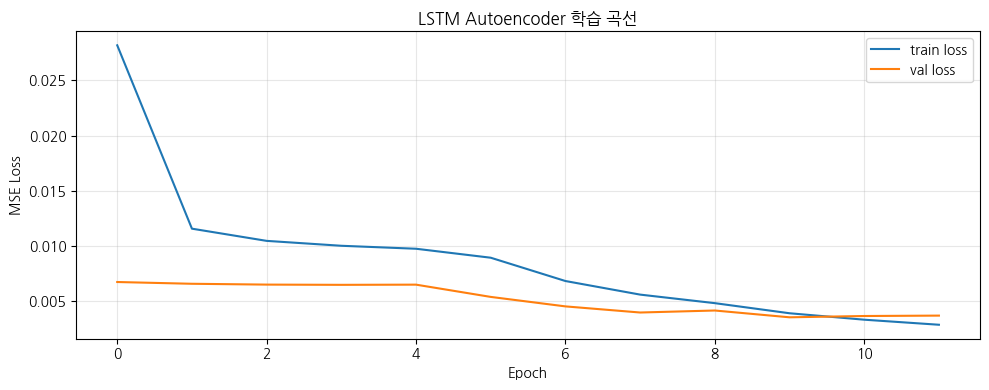


최종 train loss : 0.002871
최종 val loss   : 0.003698


In [89]:
# ── LSTM Autoencoder 학습 ──
ckpt_dir = os.path.join(os.getcwd(), 'checkpoints_lstm')
os.makedirs(ckpt_dir, exist_ok=True)

callbacks = [
    # val_loss 기준 Early Stopping
    EarlyStopping(
        monitor='val_loss',
        patience=2,
        min_delta=1e-5,
        restore_best_weights=True,  # 자동으로 best 가중치 롤백
        verbose=1
    ),
    # 에포크마다 best 모델 저장
    ModelCheckpoint(
        filepath=os.path.join(ckpt_dir, 'best_model.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print(f"학습 시작 | train={X_train_all.shape}, batch={BATCH_SIZE}, epochs={EPOCHS}")
print("=" * 60)

history = model.fit(
    X_train_all, X_train_all,   # Autoencoder: 입력 = 타깃
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,       # 10%를 validation으로
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

# 학습 곡선
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='train loss')
ax.plot(history.history['val_loss'], label='val loss')
ax.set_title('LSTM Autoencoder 학습 곡선')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n최종 train loss : {history.history['loss'][-1]:.6f}")
print(f"최종 val loss   : {history.history['val_loss'][-1]:.6f}")

train 재구성 오차 계산 중 ...
train 오차 통계:
  mean   = 0.002453
  std    = 0.001705
  99%    = 0.007979
  99.5%  = 0.009644
  99.9%  = 0.011729
  임계값 (99.5%) = 0.009644


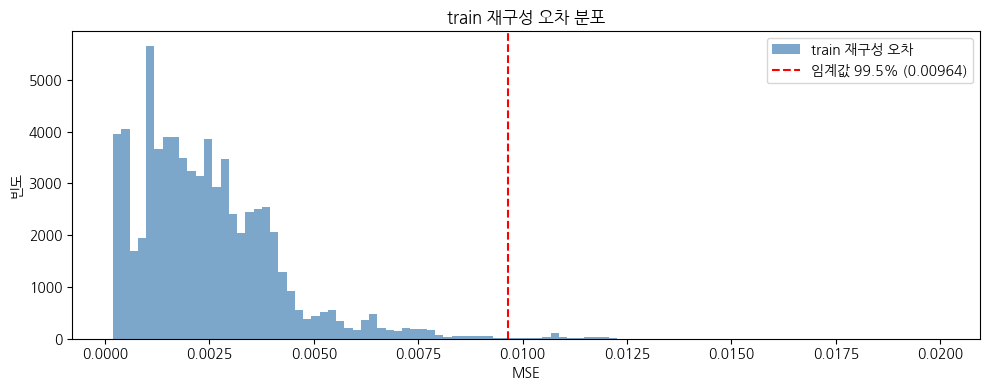

In [90]:
# ── train 재구성 오차 분포로 임계값 결정 ──
print("train 재구성 오차 계산 중 ...")
X_pred_train = model.predict(X_train_all, batch_size=BATCH_SIZE, verbose=0)
train_errors = np.mean(np.mean((X_train_all - X_pred_train) ** 2, axis=2), axis=1)

THRESHOLD_PERCENTILE = 99.5
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

# val loss와 비교해서 임계값이 너무 낮으면 val loss 기준으로 조정
if threshold < history.history['val_loss'][-1]:
    threshold = history.history['val_loss'][-1] * 1.5
    print(f"임계값이 너무 낮아 val_loss 기준으로 조정: {threshold:.6f}")

print(f"train 오차 통계:")
print(f"  mean   = {train_errors.mean():.6f}")
print(f"  std    = {train_errors.std():.6f}")
print(f"  99%    = {np.percentile(train_errors, 99):.6f}")
print(f"  99.5%  = {np.percentile(train_errors, 99.5):.6f}")
print(f"  99.9%  = {np.percentile(train_errors, 99.9):.6f}")
print(f"  임계값 ({THRESHOLD_PERCENTILE}%) = {threshold:.6f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_errors, bins=100, alpha=0.7, color='steelblue', label='train 재구성 오차')
ax.axvline(threshold, color='red', linestyle='--',
           label=f'임계값 {THRESHOLD_PERCENTILE}% ({threshold:.5f})')
ax.set_title('train 재구성 오차 분포')
ax.set_xlabel('MSE')
ax.set_ylabel('빈도')
ax.legend()
plt.tight_layout()
plt.show()

In [91]:
# ── test 이상탐지 실행 ──
register_matplotlib_converters()

TEST_DIR  = os.path.join(HOME, 'data', 'raw_data', 'test')
LABEL_DIR = os.path.join(HOME, 'data', 'preprocessed', 'test')


def detect_anomalies_lstm(df, label=''):
    """
    DataFrame → 파생변수 → 스케일링 → LSTM Autoencoder 재구성 오차 → 이상 구간
    """
    df = add_derived_features(df)
    dc = list(dict.fromkeys(get_derived_cols(df)))

    X_sc  = scaler.transform(imputer.transform(df[dc]))
    # test는 step=1로 촘촘하게 (이상 구간 정밀 탐지)
    X_seq = make_sequences(X_sc, WIN_SIZE, step_size=1)

    if len(X_seq) == 0:
        print(f"[{label}] 데이터 부족")
        return [], np.array([])

    # 재구성 오차 계산
    X_pred  = model.predict(X_seq, batch_size=BATCH_SIZE, verbose=0)
    errors  = np.mean(np.mean((X_seq - X_pred) ** 2, axis=2), axis=1)

    # 임계값 초과 구간 → 이상 구간
    is_anomaly = errors > threshold
    anomalies  = []
    in_ng      = False
    for t in range(len(is_anomaly)):
        if is_anomaly[t] and not in_ng:
            ng_start = t; in_ng = True
        elif not is_anomaly[t] and in_ng:
            anomalies.append((ng_start, t - 1))
            in_ng = False
    if in_ng:
        anomalies.append((ng_start, len(is_anomaly) - 1))

    print(f"[{label}] 시퀀스={len(X_seq)}, 탐지 구간={len(anomalies)}")
    for s, e in anomalies:
        print(f"  → {s} ~ {e} (길이: {e-s+1})")

    return anomalies, errors


# ── 전체 test 실행 ──
all_results = {}

for fname in sorted(os.listdir(TEST_DIR)):
    if not fname.endswith('.csv'):
        continue
    stem       = fname.replace('.csv', '')
    label_path = os.path.join(LABEL_DIR, stem + '_Label.csv')
    if not os.path.exists(label_path):
        print(f"[skip] 라벨 없음: {fname}")
        continue

    test_df  = pd.read_csv(os.path.join(TEST_DIR, fname))
    gt_label = pd.read_csv(label_path)['label'].values

    anomalies, errors = detect_anomalies_lstm(test_df, label=stem)

    all_results[stem] = {
        'anomalies': anomalies,
        'errors'   : errors,
        'gt_label' : gt_label,
    }

# ── 요약 ──
print("\n" + "=" * 60)
print("이상탐지 요약")
print("=" * 60)
for name, res in all_results.items():
    ng_gt   = int(res['gt_label'].sum())
    ng_pred = sum(e - s + 1 for s, e in res['anomalies'])
    print(f"  {name}: GT={ng_gt}행, 예측={ng_pred}행, 구간={len(res['anomalies'])}")

[Test01_OK_chg] 시퀀스=1623, 탐지 구간=1
  → 213 ~ 1622 (길이: 1410)
[Test02_OK_dchg] 시퀀스=919, 탐지 구간=2
  → 0 ~ 166 (길이: 167)
  → 747 ~ 918 (길이: 172)
[Test03_OK_chg] 시퀀스=1321, 탐지 구간=0
[Test04_OK_dchg] 시퀀스=1405, 탐지 구간=0
[Test05_NG_chg] 시퀀스=4916, 탐지 구간=1
  → 4463 ~ 4915 (길이: 453)
[Test06_NG_chg] 시퀀스=754, 탐지 구간=1
  → 0 ~ 753 (길이: 754)
[Test07_NG_dchg] 시퀀스=4494, 탐지 구간=1
  → 4389 ~ 4493 (길이: 105)
[Test08_NG_chg] 시퀀스=2296, 탐지 구간=2
  → 0 ~ 1332 (길이: 1333)
  → 1347 ~ 1891 (길이: 545)
[Test09_NG_dchg] 시퀀스=4764, 탐지 구간=1
  → 4399 ~ 4763 (길이: 365)

이상탐지 요약
  Test01_OK_chg: GT=0행, 예측=1410행, 구간=1
  Test02_OK_dchg: GT=0행, 예측=339행, 구간=2
  Test03_OK_chg: GT=0행, 예측=0행, 구간=0
  Test04_OK_dchg: GT=0행, 예측=0행, 구간=0
  Test05_NG_chg: GT=4259행, 예측=453행, 구간=1
  Test06_NG_chg: GT=854행, 예측=754행, 구간=1
  Test07_NG_dchg: GT=227행, 예측=105행, 구간=1
  Test08_NG_chg: GT=2396행, 예측=1878행, 구간=2
  Test09_NG_dchg: GT=4864행, 예측=365행, 구간=1


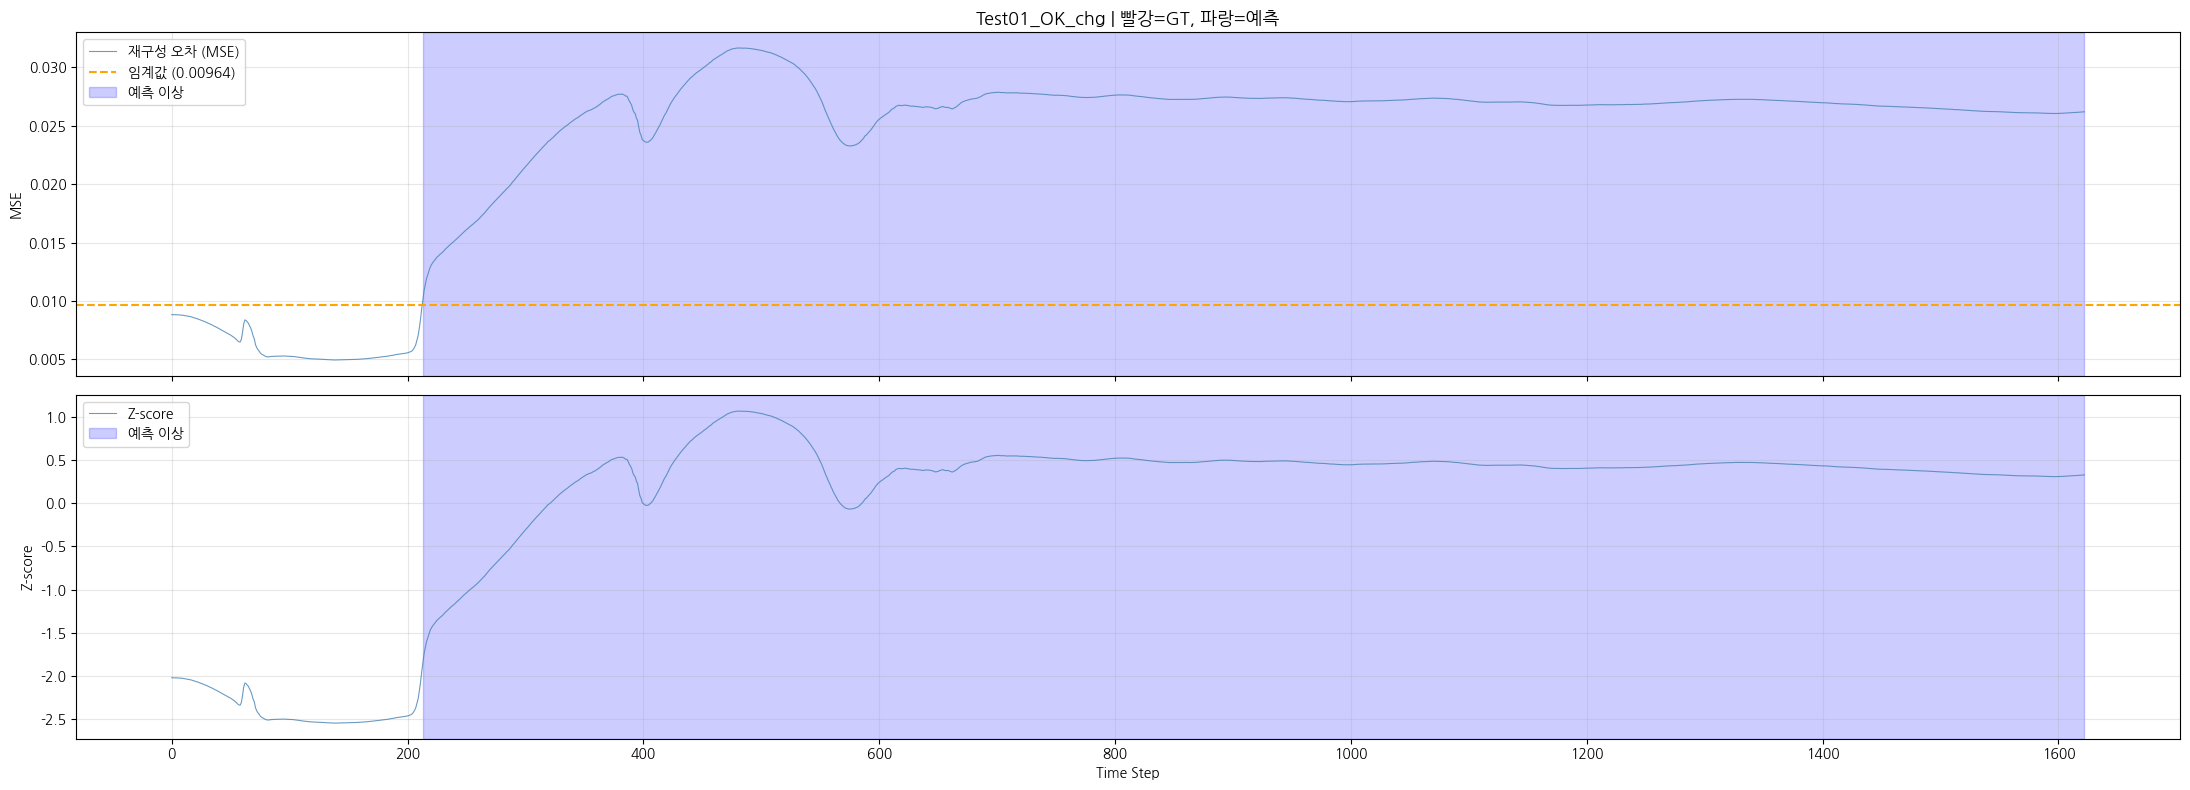

Test01_OK_chg | GT=0행, 예측=1410행



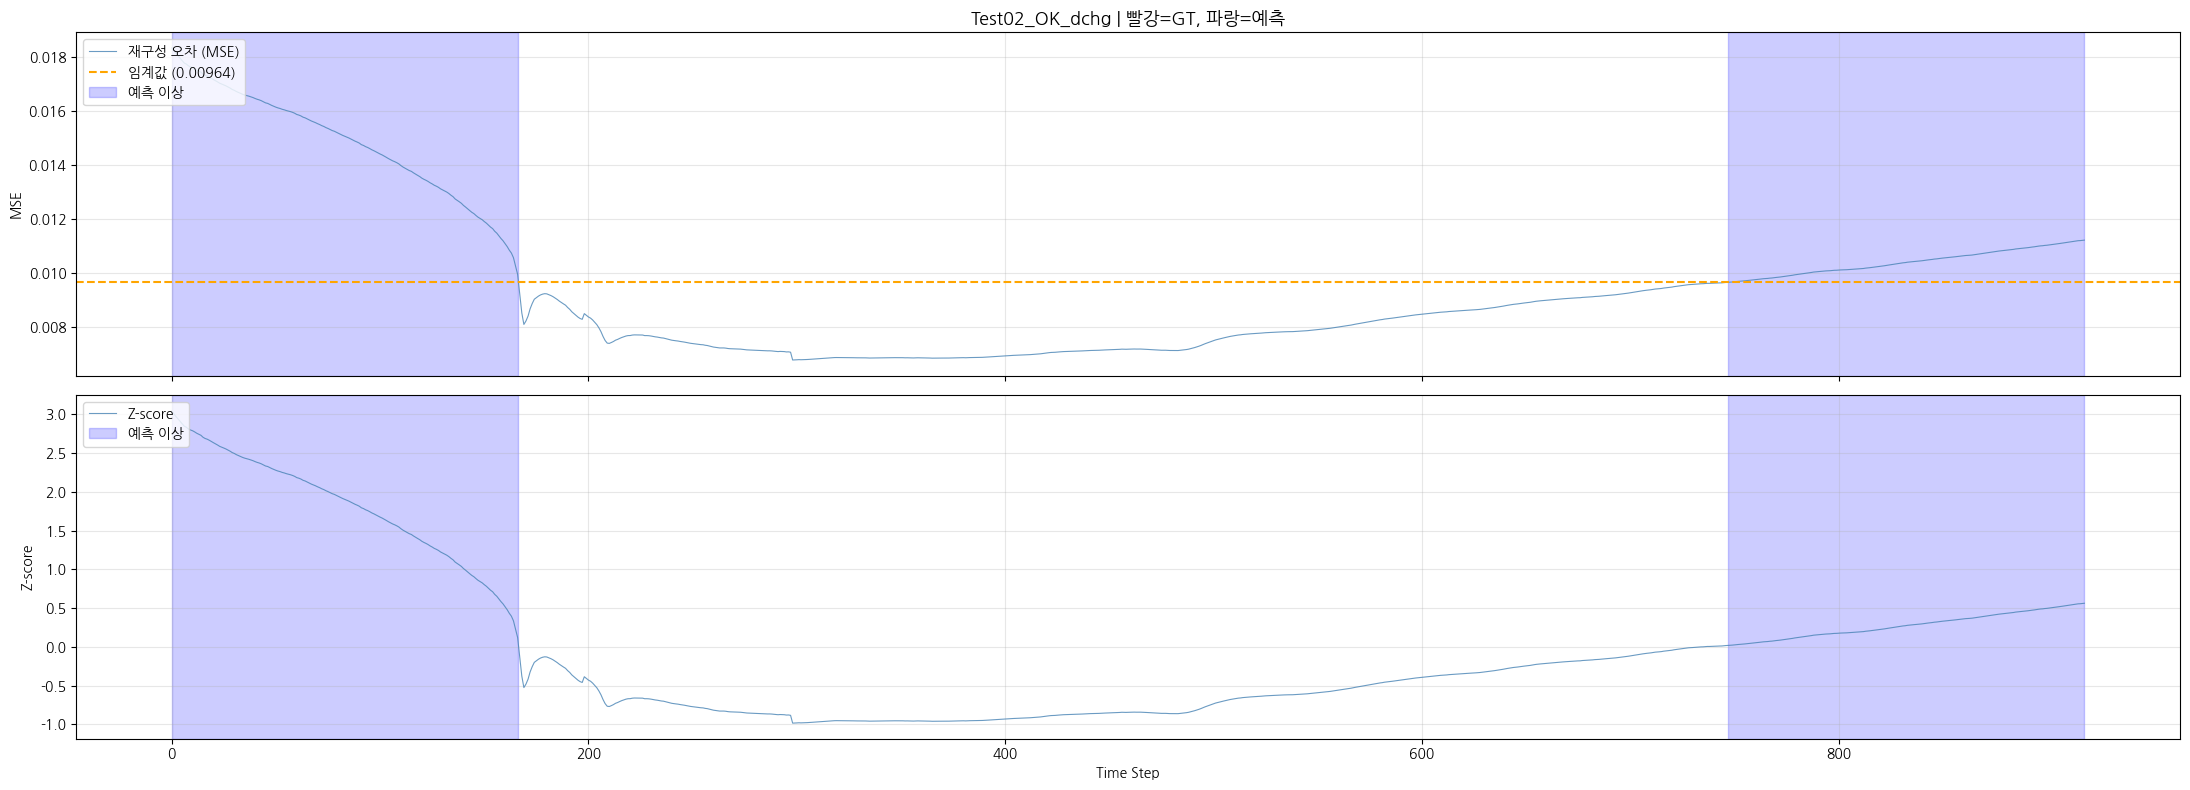

Test02_OK_dchg | GT=0행, 예측=339행



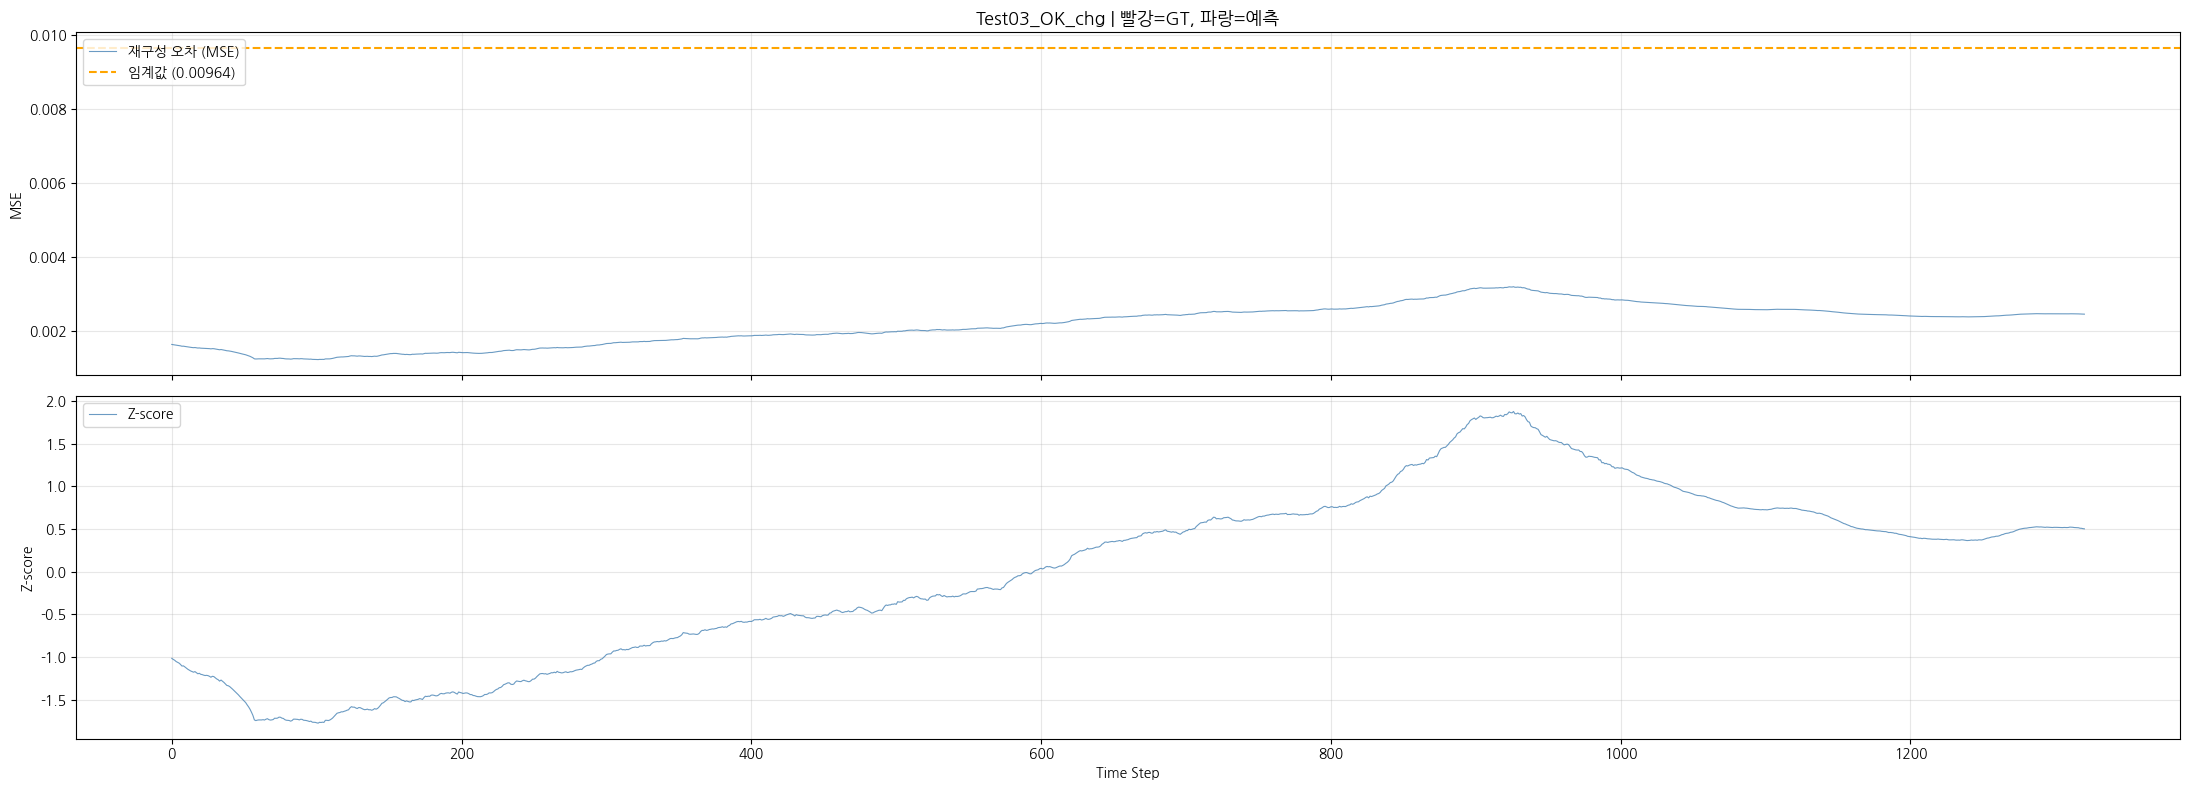

Test03_OK_chg | GT=0행, 예측=0행



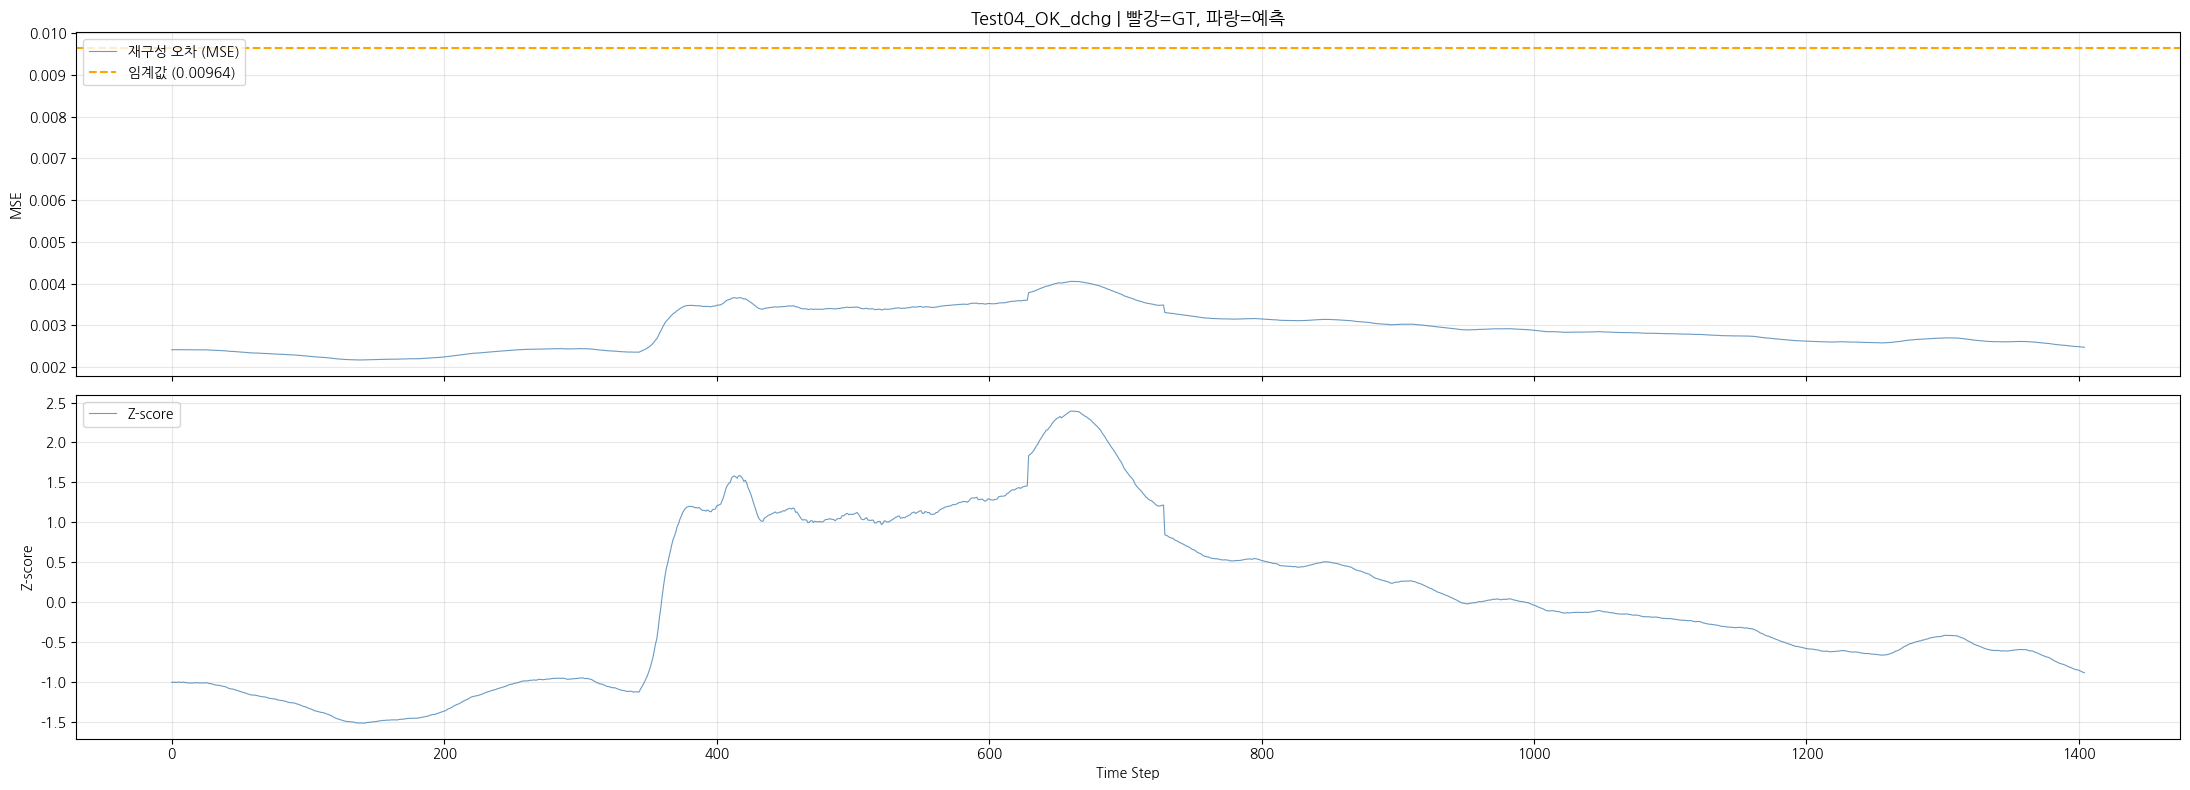

Test04_OK_dchg | GT=0행, 예측=0행



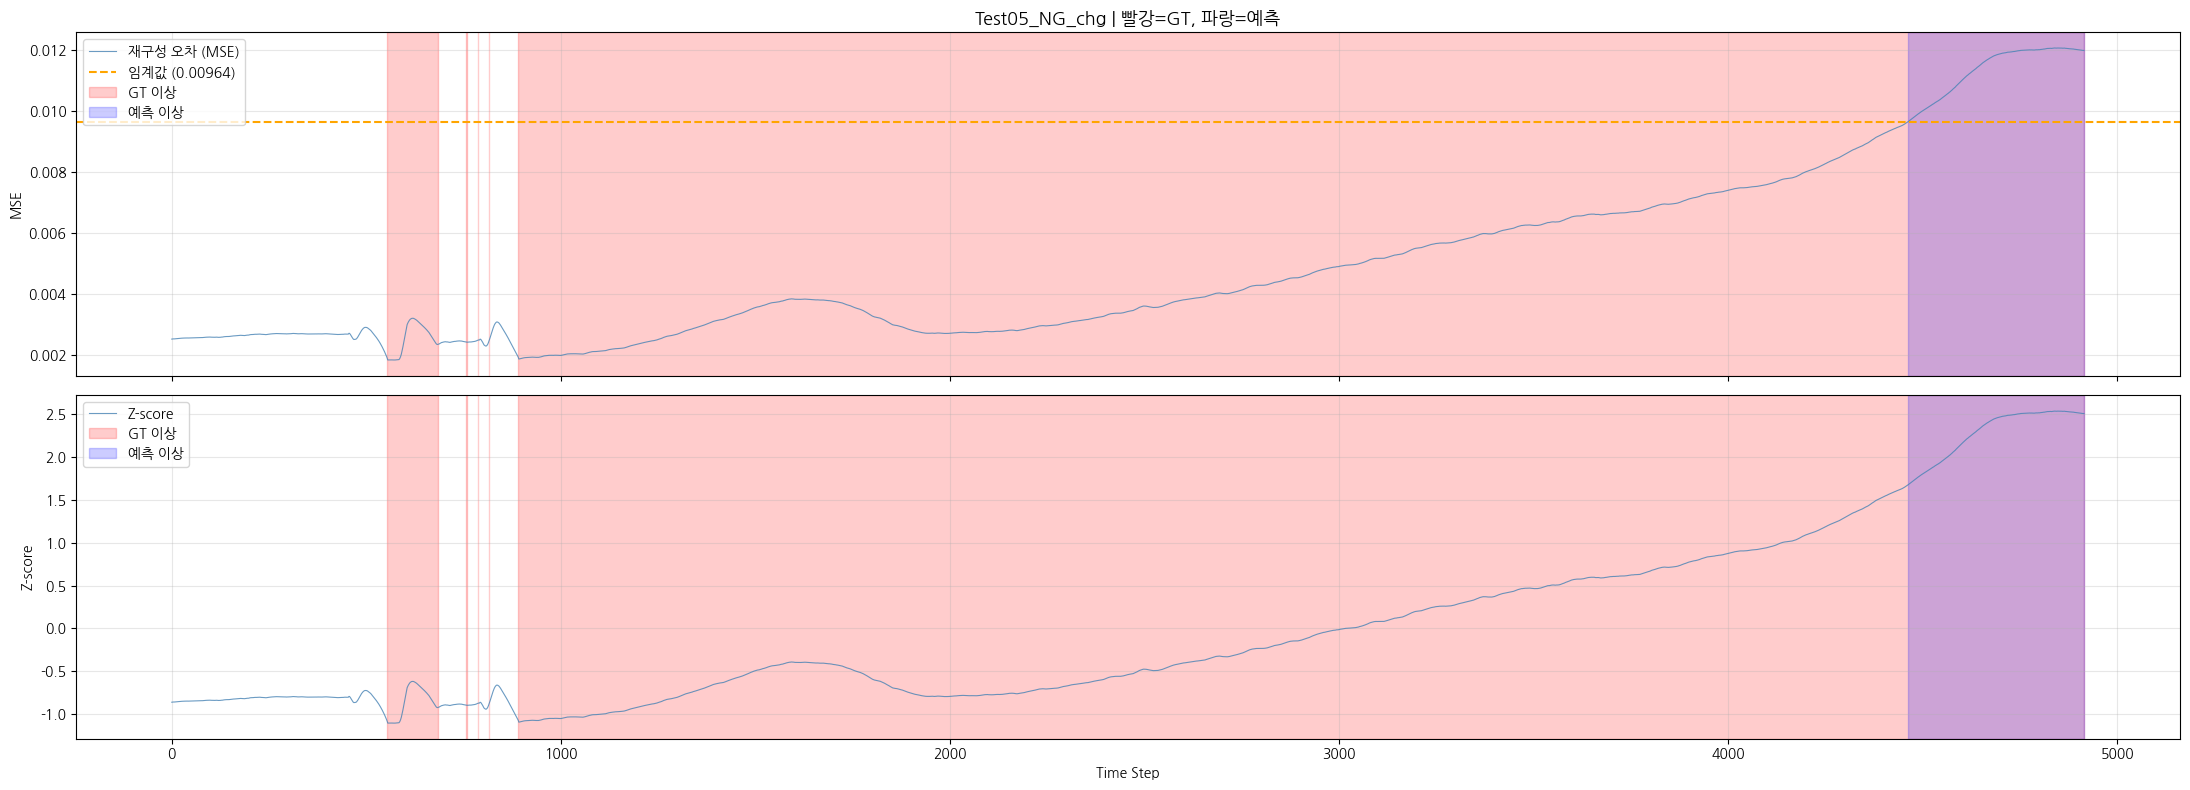

Test05_NG_chg | GT=4259행, 예측=453행



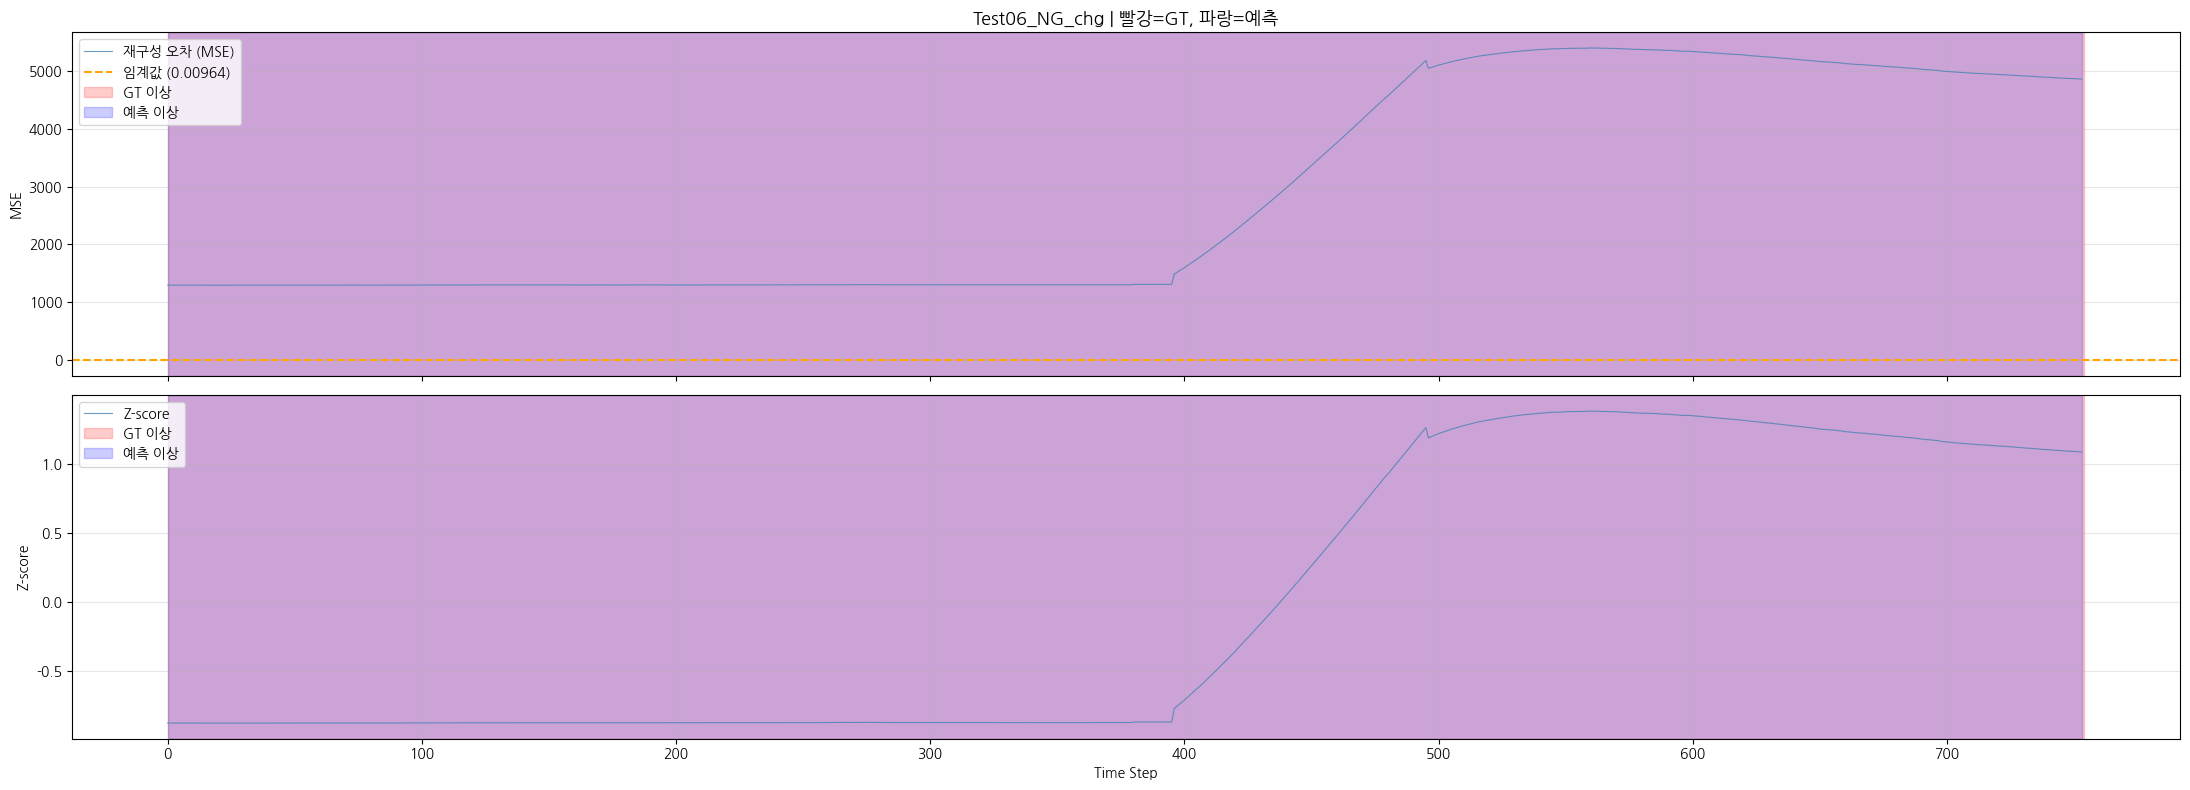

Test06_NG_chg | GT=854행, 예측=754행



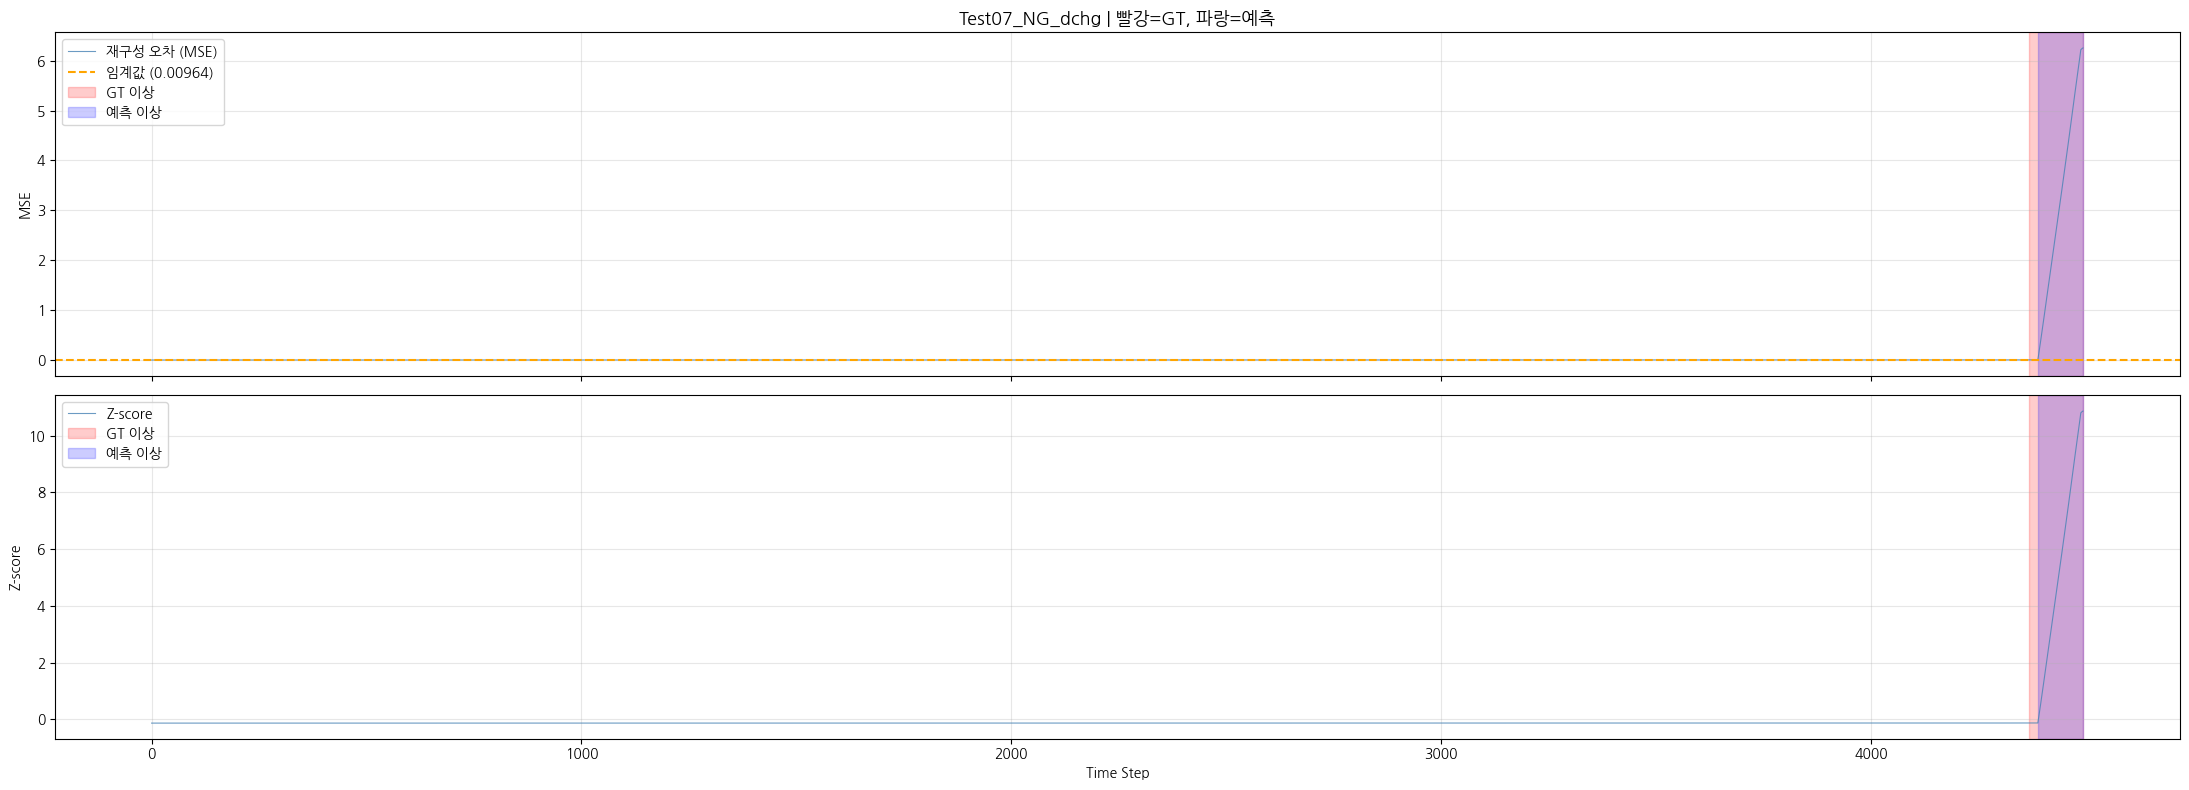

Test07_NG_dchg | GT=227행, 예측=105행



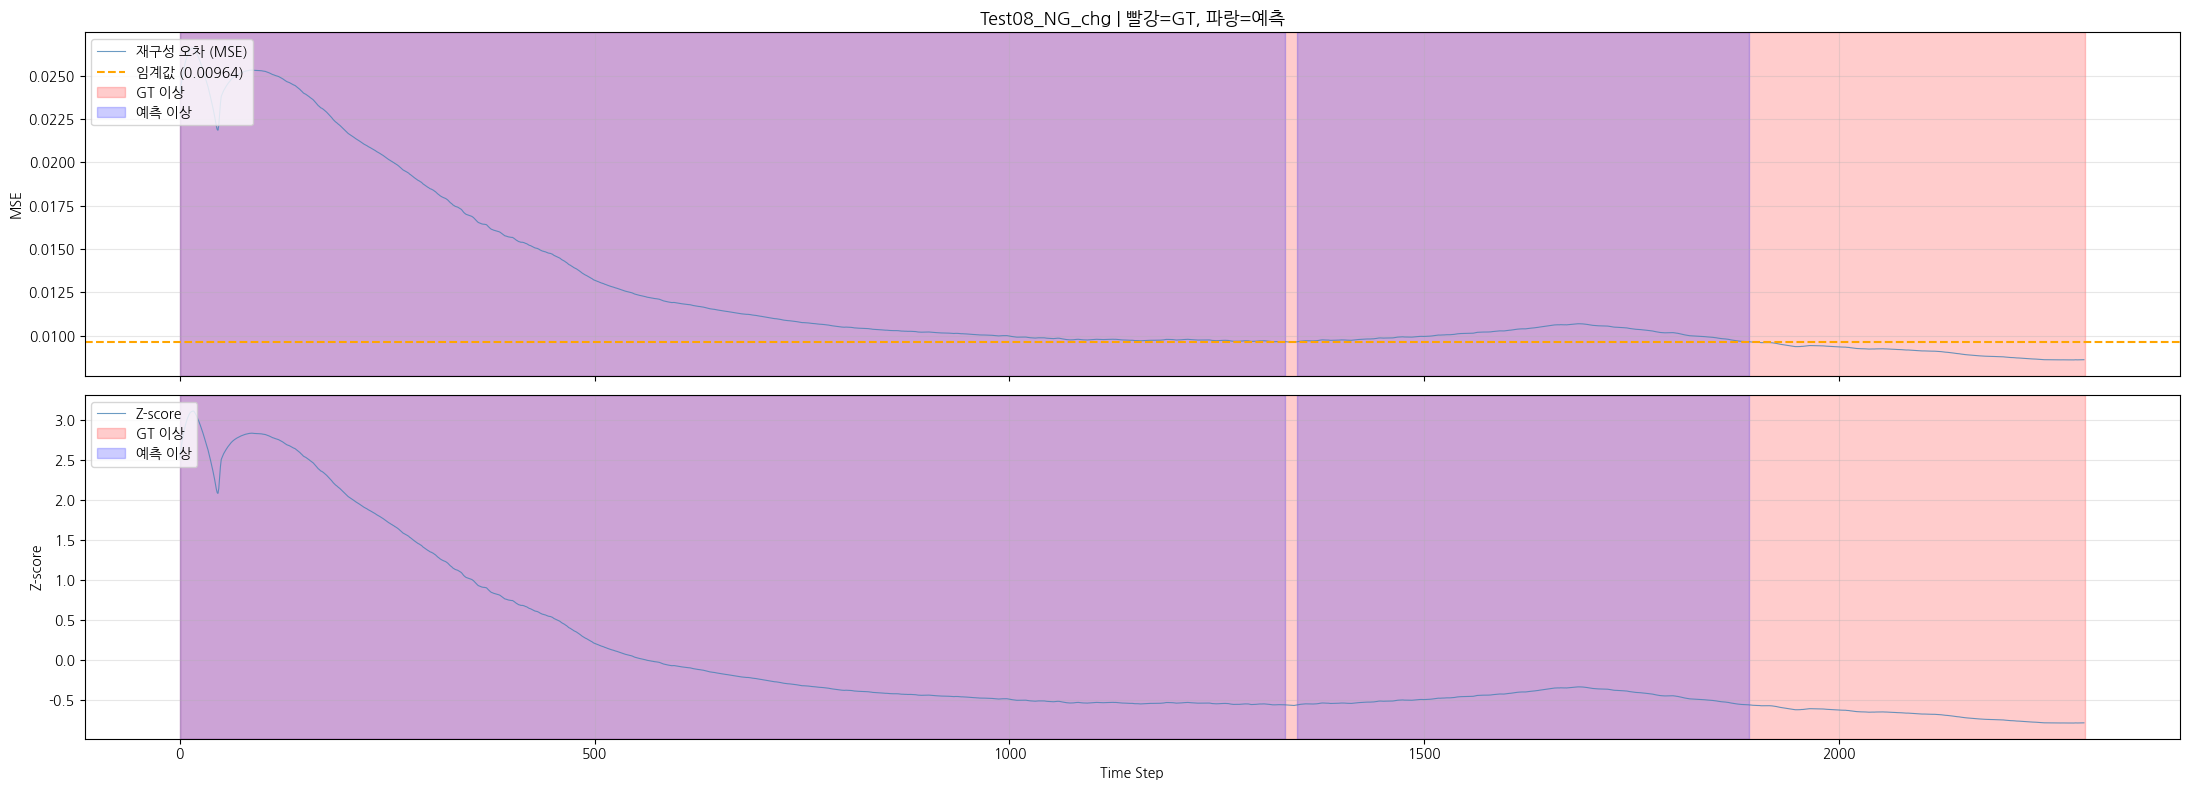

Test08_NG_chg | GT=2396행, 예측=1878행



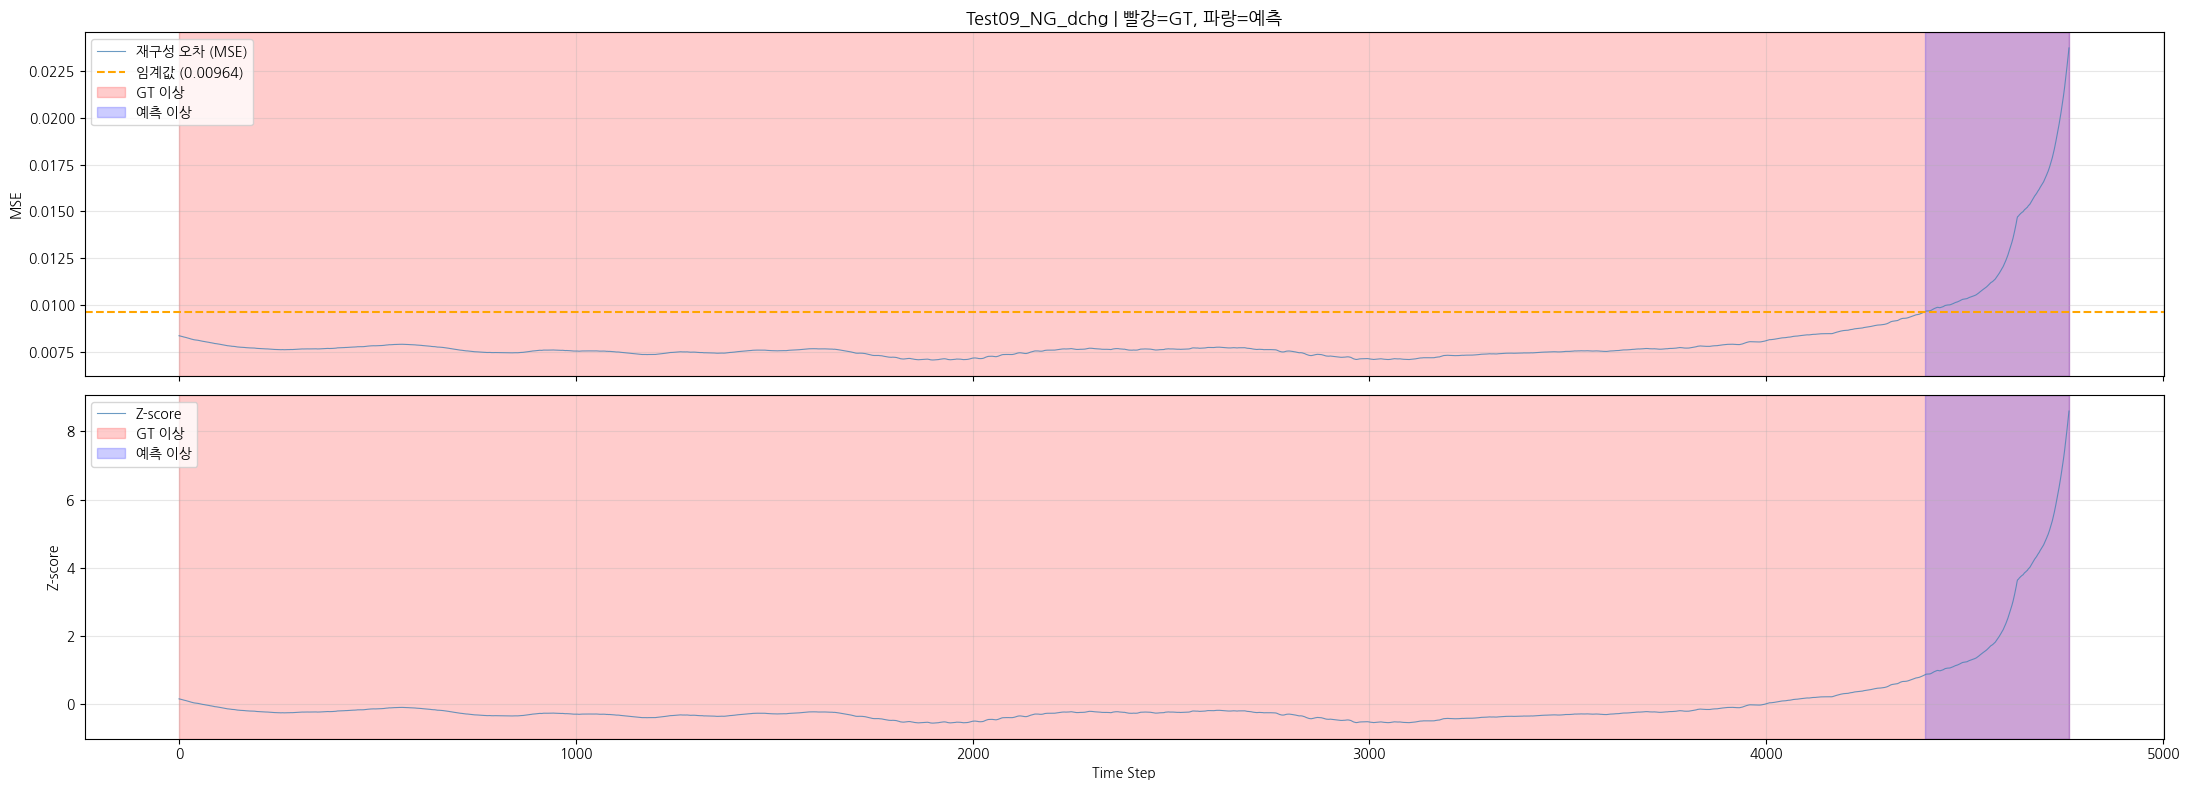

Test09_NG_dchg | GT=4864행, 예측=365행



In [92]:
# ── 결과 시각화 ──
for name, res in all_results.items():
    errors    = res['errors']
    anomalies = res['anomalies']
    gt_label  = res['gt_label']

    if len(errors) == 0:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(22, 8), sharex=True)

    # 위: 재구성 오차
    axes[0].plot(errors, color='steelblue', linewidth=0.8, alpha=0.8, label='재구성 오차 (MSE)')
    axes[0].axhline(threshold, color='orange', linestyle='--',
                    linewidth=1.5, label=f'임계값 ({threshold:.5f})')

    # 아래: Z-score
    z = (errors - errors.mean()) / (errors.std() + 1e-8)
    axes[1].plot(z, color='steelblue', linewidth=0.8, alpha=0.8, label='Z-score')

    for ax in axes:
        # GT 음영 (빨강)
        gt_len = min(len(gt_label), len(errors))
        in_ng  = False
        for t in range(gt_len):
            if gt_label[t] == 1 and not in_ng:
                ng_start = t; in_ng = True
            elif gt_label[t] == 0 and in_ng:
                ax.axvspan(ng_start, t, color='red', alpha=0.2, label='GT 이상')
                in_ng = False
        if in_ng:
            ax.axvspan(ng_start, gt_len, color='red', alpha=0.2, label='GT 이상')

        # 예측 음영 (파랑)
        for s, e in anomalies:
            ax.axvspan(max(0, s), min(e, len(errors)-1),
                       color='blue', alpha=0.2, label='예측 이상')

        handles, labels_leg = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels_leg, handles)).values(),
                  dict(zip(labels_leg, handles)).keys(), loc='upper left')
        ax.grid(True, alpha=0.3)

    axes[0].set_title(f'{name} | 빨강=GT, 파랑=예측', fontsize=13)
    axes[0].set_ylabel('MSE')
    axes[1].set_ylabel('Z-score')
    axes[1].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()

    ng_gt   = int(gt_label.sum())
    ng_pred = sum(e - s + 1 for s, e in anomalies)
    print(f"{name} | GT={ng_gt}행, 예측={ng_pred}행\n")

In [93]:
# ── 모델 저장 ──
ckpt_dir = os.path.join(os.getcwd(), 'checkpoints_lstm')
os.makedirs(ckpt_dir, exist_ok=True)

model.save(os.path.join(ckpt_dir, 'lstm_autoencoder_final.keras'))
print(f"모델 저장 완료 → {ckpt_dir}/lstm_autoencoder_final.keras")

모델 저장 완료 → /mnt/c/Users/Administrator/github/project2/checkpoints_lstm/lstm_autoencoder_final.keras


# 전압/온도 따로 학습

In [94]:
# ── 전압/온도 파생변수 분리 ──
VOLT_SUFFIXES = ('_cell_dev', '_mod_dev')
TEMP_SUFFIXES = ('_temp_dev',)

def get_volt_cols(df):
    return list(dict.fromkeys(
        [c for c in df.columns if c.endswith(VOLT_SUFFIXES)]
    ))

def get_temp_cols(df):
    return list(dict.fromkeys(
        [c for c in df.columns if c.endswith(TEMP_SUFFIXES)]
    ))

# 파생변수 생성
print("파생변수 생성 중 ...")
train_derived_list = [add_derived_features(df) for df in train_list]

# 전압 scaler fit
print("전압 Scaler fit 중 ...")
all_volt = pd.concat(
    [df[get_volt_cols(df)] for df in train_derived_list],
    ignore_index=True
).loc[:, lambda x: ~x.columns.duplicated()]

imputer_v = SimpleImputer(strategy='mean')
scaler_v  = MinMaxScaler(feature_range=(0, 1))
imputer_v.fit(all_volt)
scaler_v.fit(imputer_v.transform(all_volt))
print(f"전압 Scaler fit 완료 | 컬럼={all_volt.shape[1]}개")

# 온도 scaler fit
print("온도 Scaler fit 중 ...")
all_temp = pd.concat(
    [df[get_temp_cols(df)] for df in train_derived_list],
    ignore_index=True
).loc[:, lambda x: ~x.columns.duplicated()]

imputer_t = SimpleImputer(strategy='mean')
scaler_t  = MinMaxScaler(feature_range=(0, 1))
imputer_t.fit(all_temp)
scaler_t.fit(imputer_t.transform(all_temp))
print(f"온도 Scaler fit 완료 | 컬럼={all_temp.shape[1]}개")

# train 시퀀스 생성
print("\ntrain 시퀀스 생성 중 ...")
X_volt_list = []
X_temp_list = []

for df in train_derived_list:
    # 전압
    vc  = list(dict.fromkeys(get_volt_cols(df)))
    X_v = scaler_v.transform(imputer_v.transform(df[vc]))
    seq_v = make_sequences(X_v, WIN_SIZE, STEP_SIZE)

    # 온도
    tc  = list(dict.fromkeys(get_temp_cols(df)))
    X_t = scaler_t.transform(imputer_t.transform(df[tc]))
    seq_t = make_sequences(X_t, WIN_SIZE, STEP_SIZE)

    if len(seq_v) > 0 and len(seq_t) > 0:
        X_volt_list.append(seq_v)
        X_temp_list.append(seq_t)

X_train_volt = np.concatenate(X_volt_list, axis=0)
X_train_temp = np.concatenate(X_temp_list, axis=0)

print(f"전압 시퀀스 shape: {X_train_volt.shape}  ({X_train_volt.nbytes/1024**2:.1f} MB)")
print(f"온도 시퀀스 shape: {X_train_temp.shape}  ({X_train_temp.nbytes/1024**2:.1f} MB)")

파생변수 생성 중 ...
전압 Scaler fit 중 ...
전압 Scaler fit 완료 | 컬럼=32개
온도 Scaler fit 중 ...
온도 Scaler fit 완료 | 컬럼=16개

train 시퀀스 생성 중 ...
전압 시퀀스 shape: (71109, 100, 32)  (868.0 MB)
온도 시퀀스 shape: (71109, 100, 16)  (434.0 MB)


Model: "volt_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 100, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 100, 32)        │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,536 (287.25 KB)

 Trainable params: 73,536 (287.25 KB)

 Non-trainable params: 0 (0.00 B)


전압 모델 학습 시작 ...
Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - loss: 0.0588 - val_loss: 0.0189 - learning_rate: 1.0000e-04
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - loss: 0.0215 - val_loss: 0.0131 - learning_rate: 1.0000e-04
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 0.0149 - val_loss: 0.0091 - learning_rate: 1.0000e-04
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - loss: 0.0114 - val_loss: 0.0072 - learning_rate: 1.0000e-04
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 0.0093 - val_loss: 0.0061 - learning_rate: 1.0000e-04
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - loss: 0.0080 - val_loss: 0.0053 - learning_rate: 1.0000e-04
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - loss: 0.0070 - val_loss: 0.0048 - learning_rate: 1.0000e-04
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - loss: 0.0063 - val_loss: 0.0046 - learning_rate: 1.0000e-04
Epoch 9/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step -

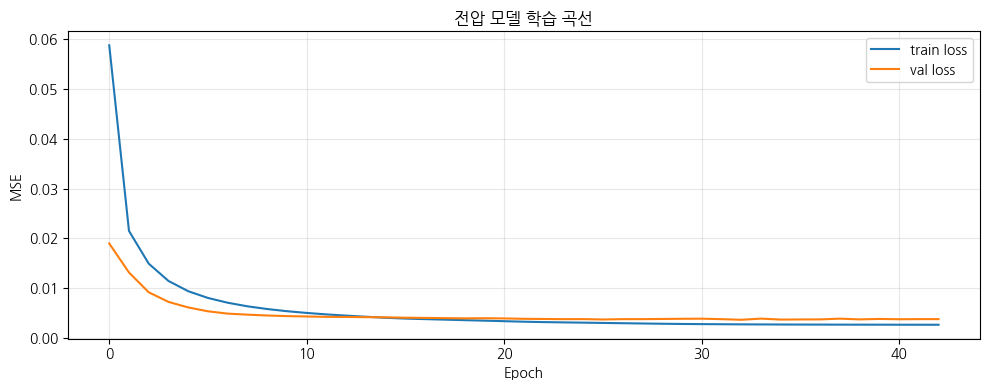

최종 train=0.002589, val=0.003723


In [95]:
# ── 전압 모델 빌드 ──
VOLT_DIM = X_train_volt.shape[2]   # 32 (cell_dev 16 + mod_dev 16)
TEMP_DIM = X_train_temp.shape[2]   # 16 (temp_dev 16)

def build_lstm_autoencoder(window_size, features_dim, latent_dim, name='model'):
    inputs = Input(shape=(window_size, features_dim), name='input')

    x = LSTM(64, return_sequences=True, name='enc_lstm1')(inputs)
    x = Dropout(0.2)(x)
    x = LSTM(32, return_sequences=False, name='enc_lstm2')(x)
    x = Dropout(0.2)(x)
    encoded = Dense(latent_dim, activation='relu', name='latent')(x)

    x = RepeatVector(window_size, name='repeat')(encoded)
    x = LSTM(32, return_sequences=True, name='dec_lstm1')(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True, name='dec_lstm2')(x)
    x = Dropout(0.2)(x)
    decoded = TimeDistributed(Dense(features_dim), name='output')(x)

    model = Model(inputs, decoded, name=name)
    return model


# 전압 모델
model_volt = build_lstm_autoencoder(WIN_SIZE, VOLT_DIM, LATENT_DIM, name='volt_autoencoder')
model_volt.compile(optimizer=tf.keras.optimizers.Adam(0.0001), loss='mse')
model_volt.summary()

# 학습
print("\n전압 모델 학습 시작 ...")
callbacks_volt = [
    EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=os.path.join(ckpt_dir, 'best_volt_model.keras'),
                    monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history_volt = model_volt.fit(
    X_train_volt, X_train_volt,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks_volt,
    shuffle=True,
    verbose=1
)

# 학습 곡선
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_volt.history['loss'],     label='train loss')
ax.plot(history_volt.history['val_loss'], label='val loss')
ax.set_title('전압 모델 학습 곡선')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"최종 train={history_volt.history['loss'][-1]:.6f}, val={history_volt.history['val_loss'][-1]:.6f}")

Model: "temp_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 100, 64)        │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 100, 32)        │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 100, 16)        │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,400 (267.19 KB)

 Trainable params: 68,400 (267.19 KB)

 Non-trainable params: 0 (0.00 B)


온도 모델 학습 시작 ...
Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 0.0994 - val_loss: 0.0224 - learning_rate: 1.0000e-04
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 22s 97ms/step - loss: 0.0370 - val_loss: 0.0181 - learning_rate: 1.0000e-04
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - loss: 0.0295 - val_loss: 0.0154 - learning_rate: 1.0000e-04
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - loss: 0.0253 - val_loss: 0.0142 - learning_rate: 1.0000e-04
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - loss: 0.0227 - val_loss: 0.0135 - learning_rate: 1.0000e-04
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - loss: 0.0209 - val_loss: 0.0123 - learning_rate: 1.0000e-04
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step - loss: 0.0185 - val_loss: 0.0090 - learning_rate: 1.0000e-04
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 0.0168 - val_loss: 0.0083 - learning_rate: 1.0000e-04
Epoch 9/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step -

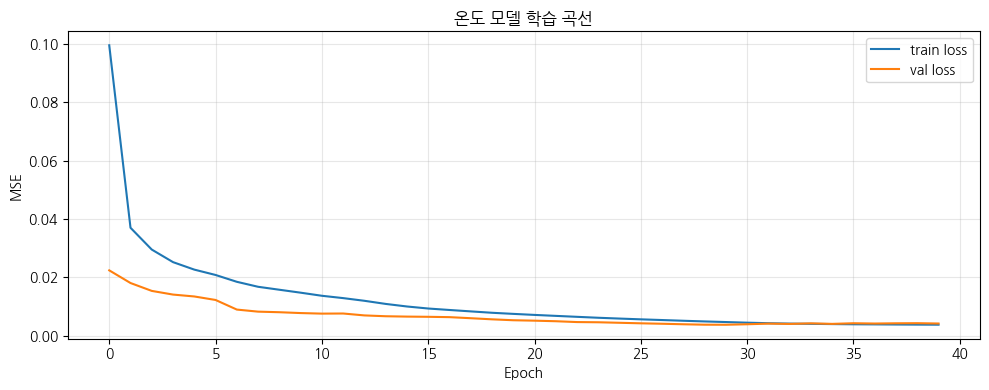

최종 train=0.003858, val=0.004259


In [96]:
# ── 온도 모델 빌드 및 학습 ──
model_temp = build_lstm_autoencoder(WIN_SIZE, TEMP_DIM, LATENT_DIM, name='temp_autoencoder')
model_temp.compile(optimizer=tf.keras.optimizers.Adam(0.0001), loss='mse')
model_temp.summary()

print("\n온도 모델 학습 시작 ...")
callbacks_temp = [
    EarlyStopping(monitor='val_loss', patience=10, min_delta=1e-6,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=os.path.join(ckpt_dir, 'best_temp_model.keras'),
                    monitor='val_loss', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

history_temp = model_temp.fit(
    X_train_temp, X_train_temp,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=callbacks_temp,
    shuffle=True,
    verbose=1
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_temp.history['loss'],     label='train loss')
ax.plot(history_temp.history['val_loss'], label='val loss')
ax.set_title('온도 모델 학습 곡선')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"최종 train={history_temp.history['loss'][-1]:.6f}, val={history_temp.history['val_loss'][-1]:.6f}")

train 재구성 오차 계산 중 ...

전압 임계값: 0.012923
온도 임계값: 0.012408


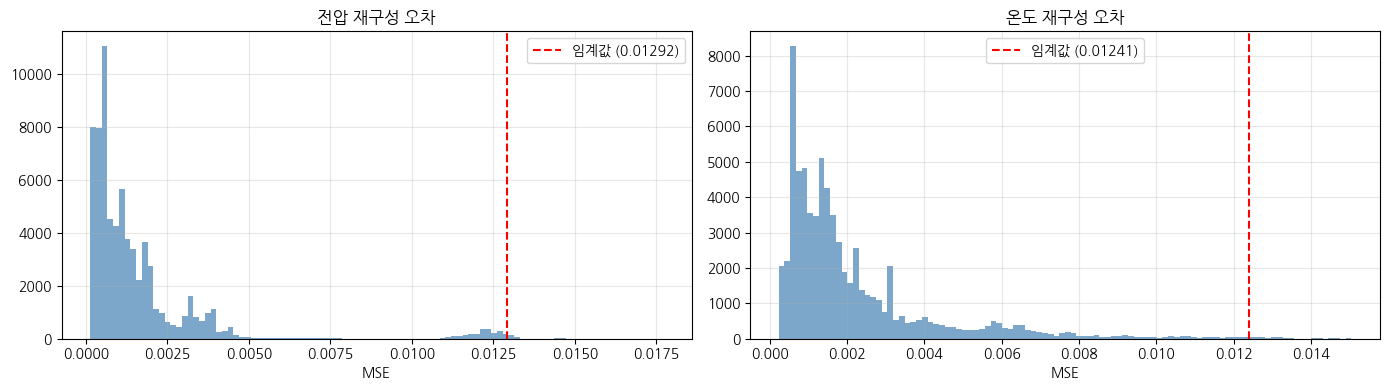

In [97]:
# ── 전압/온도 각각 임계값 설정 ──
print("train 재구성 오차 계산 중 ...")

# 전압 임계값
X_pred_volt  = model_volt.predict(X_train_volt, batch_size=BATCH_SIZE, verbose=0)
errors_volt  = np.mean(np.mean((X_train_volt - X_pred_volt) ** 2, axis=2), axis=1)
threshold_v  = np.percentile(errors_volt, 99.5)
if threshold_v < history_volt.history['val_loss'][-1]:
    threshold_v = history_volt.history['val_loss'][-1] * 1.5
    print(f"전압 임계값 val_loss 기준 조정: {threshold_v:.6f}")

# 온도 임계값
X_pred_temp  = model_temp.predict(X_train_temp, batch_size=BATCH_SIZE, verbose=0)
errors_temp  = np.mean(np.mean((X_train_temp - X_pred_temp) ** 2, axis=2), axis=1)
threshold_t  = np.percentile(errors_temp, 99.5)
if threshold_t < history_temp.history['val_loss'][-1]:
    threshold_t = history_temp.history['val_loss'][-1] * 1.5
    print(f"온도 임계값 val_loss 기준 조정: {threshold_t:.6f}")

print(f"\n전압 임계값: {threshold_v:.6f}")
print(f"온도 임계값: {threshold_t:.6f}")

# 오차 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, errors, threshold, title in zip(
    axes,
    [errors_volt, errors_temp],
    [threshold_v, threshold_t],
    ['전압 재구성 오차', '온도 재구성 오차']
):
    ax.hist(errors, bins=100, alpha=0.7, color='steelblue')
    ax.axvline(threshold, color='red', linestyle='--',
               label=f'임계값 ({threshold:.5f})')
    ax.set_title(title); ax.set_xlabel('MSE')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [98]:
# ── test 이상탐지 실행 (전압 + 온도 합산) ──
def detect_anomalies_dual(df, label=''):
    """전압/온도 모델 각각 재구성 오차 계산 후 합산"""
    df = add_derived_features(df)

    # 전압 시퀀스
    vc    = list(dict.fromkeys(get_volt_cols(df)))
    X_v   = scaler_v.transform(imputer_v.transform(df[vc]))
    seq_v = make_sequences(X_v, WIN_SIZE, step_size=1)

    # 온도 시퀀스
    tc    = list(dict.fromkeys(get_temp_cols(df)))
    X_t   = scaler_t.transform(imputer_t.transform(df[tc]))
    seq_t = make_sequences(X_t, WIN_SIZE, step_size=1)

    if len(seq_v) == 0 or len(seq_t) == 0:
        print(f"[{label}] 데이터 부족")
        return [], np.array([]), np.array([]), np.array([])

    # 재구성 오차
    pred_v = model_volt.predict(seq_v, batch_size=BATCH_SIZE, verbose=0)
    pred_t = model_temp.predict(seq_t, batch_size=BATCH_SIZE, verbose=0)

    huber  = tf.keras.losses.Huber()
    err_v  = np.array([float(huber(seq_v[i], pred_v[i]).numpy()) for i in range(len(seq_v))])
    err_t  = np.array([float(huber(seq_t[i], pred_t[i]).numpy()) for i in range(len(seq_t))])

    # 각각 정규화 후 합산
    z_v = (err_v - err_v.mean()) / (err_v.std() + 1e-8)
    z_t = (err_t - err_t.mean()) / (err_t.std() + 1e-8)
    combined = z_v + z_t   # 합산

    # 임계값 초과 구간 → 이상 구간
    # 각각 임계값 초과 여부 OR 조건
    is_anomaly = (err_v > threshold_v) | (err_t > threshold_t)
    anomalies  = []
    in_ng      = False
    for t in range(len(is_anomaly)):
        if is_anomaly[t] and not in_ng:
            ng_start = t; in_ng = True
        elif not is_anomaly[t] and in_ng:
            anomalies.append((ng_start, t - 1))
            in_ng = False
    if in_ng:
        anomalies.append((ng_start, len(is_anomaly) - 1))

    print(f"[{label}] 탐지 구간={len(anomalies)}")
    for s, e in anomalies:
        print(f"  → {s} ~ {e} (길이: {e-s+1})")

    return anomalies, err_v, err_t, combined


# ── 전체 test 실행 ──
all_results = {}

for fname in sorted(os.listdir(TEST_DIR)):
    if not fname.endswith('.csv'):
        continue
    stem       = fname.replace('.csv', '')
    label_path = os.path.join(LABEL_DIR, stem + '_Label.csv')
    if not os.path.exists(label_path):
        print(f"[skip] 라벨 없음: {fname}")
        continue

    test_df  = pd.read_csv(os.path.join(TEST_DIR, fname))
    gt_label = pd.read_csv(label_path)['label'].values

    anomalies, err_v, err_t, combined = detect_anomalies_dual(test_df, label=stem)

    all_results[stem] = {
        'anomalies': anomalies,
        'err_volt' : err_v,
        'err_temp' : err_t,
        'combined' : combined,
        'gt_label' : gt_label,
    }

print("\n" + "=" * 60)
print("이상탐지 요약")
print("=" * 60)
for name, res in all_results.items():
    ng_gt   = int(res['gt_label'].sum())
    ng_pred = sum(e - s + 1 for s, e in res['anomalies'])
    print(f"  {name}: GT={ng_gt}행, 예측={ng_pred}행, 구간={len(res['anomalies'])}")

[Test01_OK_chg] 탐지 구간=1
  → 431 ~ 620 (길이: 190)
[Test02_OK_dchg] 탐지 구간=0
[Test03_OK_chg] 탐지 구간=0
[Test04_OK_dchg] 탐지 구간=0
[Test05_NG_chg] 탐지 구간=0
[Test06_NG_chg] 탐지 구간=1
  → 0 ~ 753 (길이: 754)
[Test07_NG_dchg] 탐지 구간=1
  → 4391 ~ 4493 (길이: 103)
[Test08_NG_chg] 탐지 구간=1
  → 29 ~ 189 (길이: 161)
[Test09_NG_dchg] 탐지 구간=2
  → 4563 ~ 4567 (길이: 5)
  → 4587 ~ 4763 (길이: 177)

이상탐지 요약
  Test01_OK_chg: GT=0행, 예측=190행, 구간=1
  Test02_OK_dchg: GT=0행, 예측=0행, 구간=0
  Test03_OK_chg: GT=0행, 예측=0행, 구간=0
  Test04_OK_dchg: GT=0행, 예측=0행, 구간=0
  Test05_NG_chg: GT=4259행, 예측=0행, 구간=0
  Test06_NG_chg: GT=854행, 예측=754행, 구간=1
  Test07_NG_dchg: GT=227행, 예측=103행, 구간=1
  Test08_NG_chg: GT=2396행, 예측=161행, 구간=1
  Test09_NG_dchg: GT=4864행, 예측=182행, 구간=2


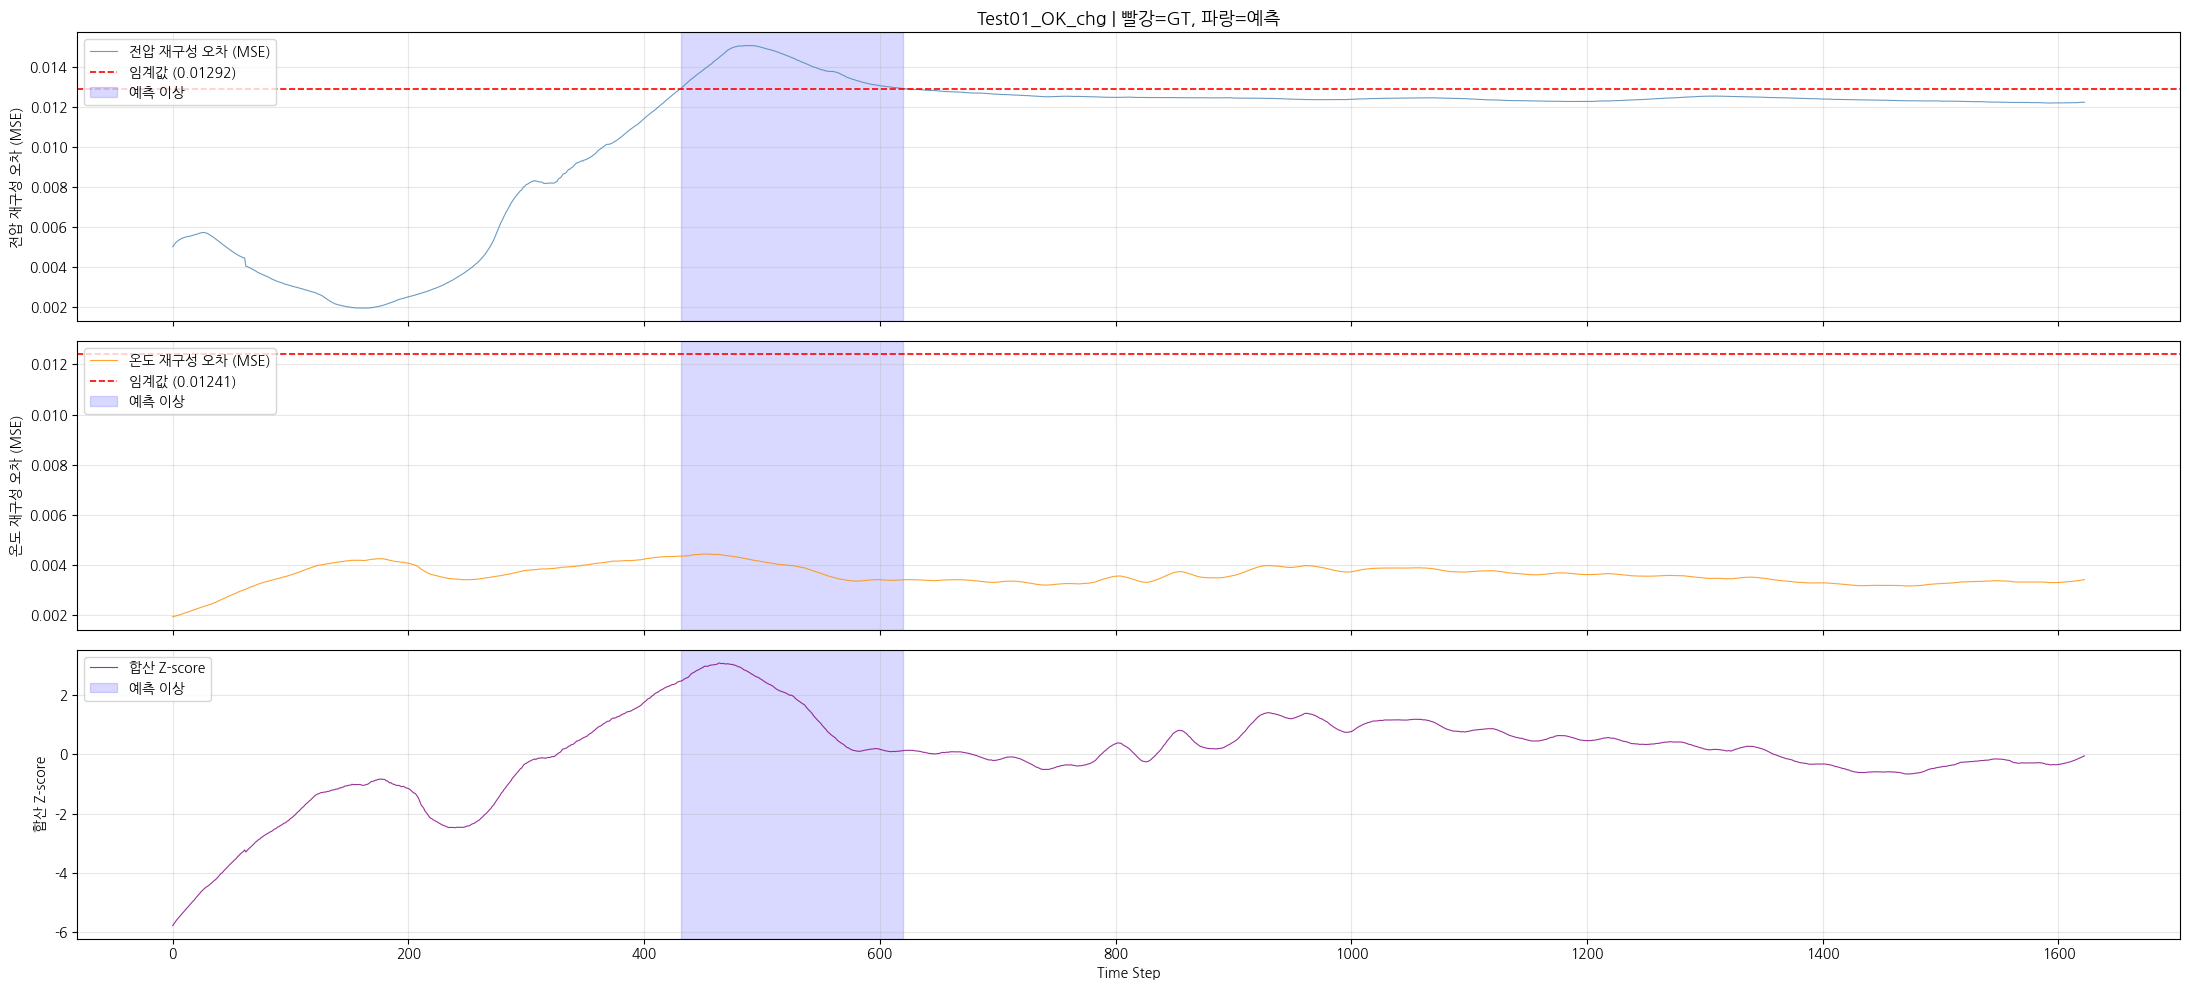

Test01_OK_chg | GT=0행, 예측=190행



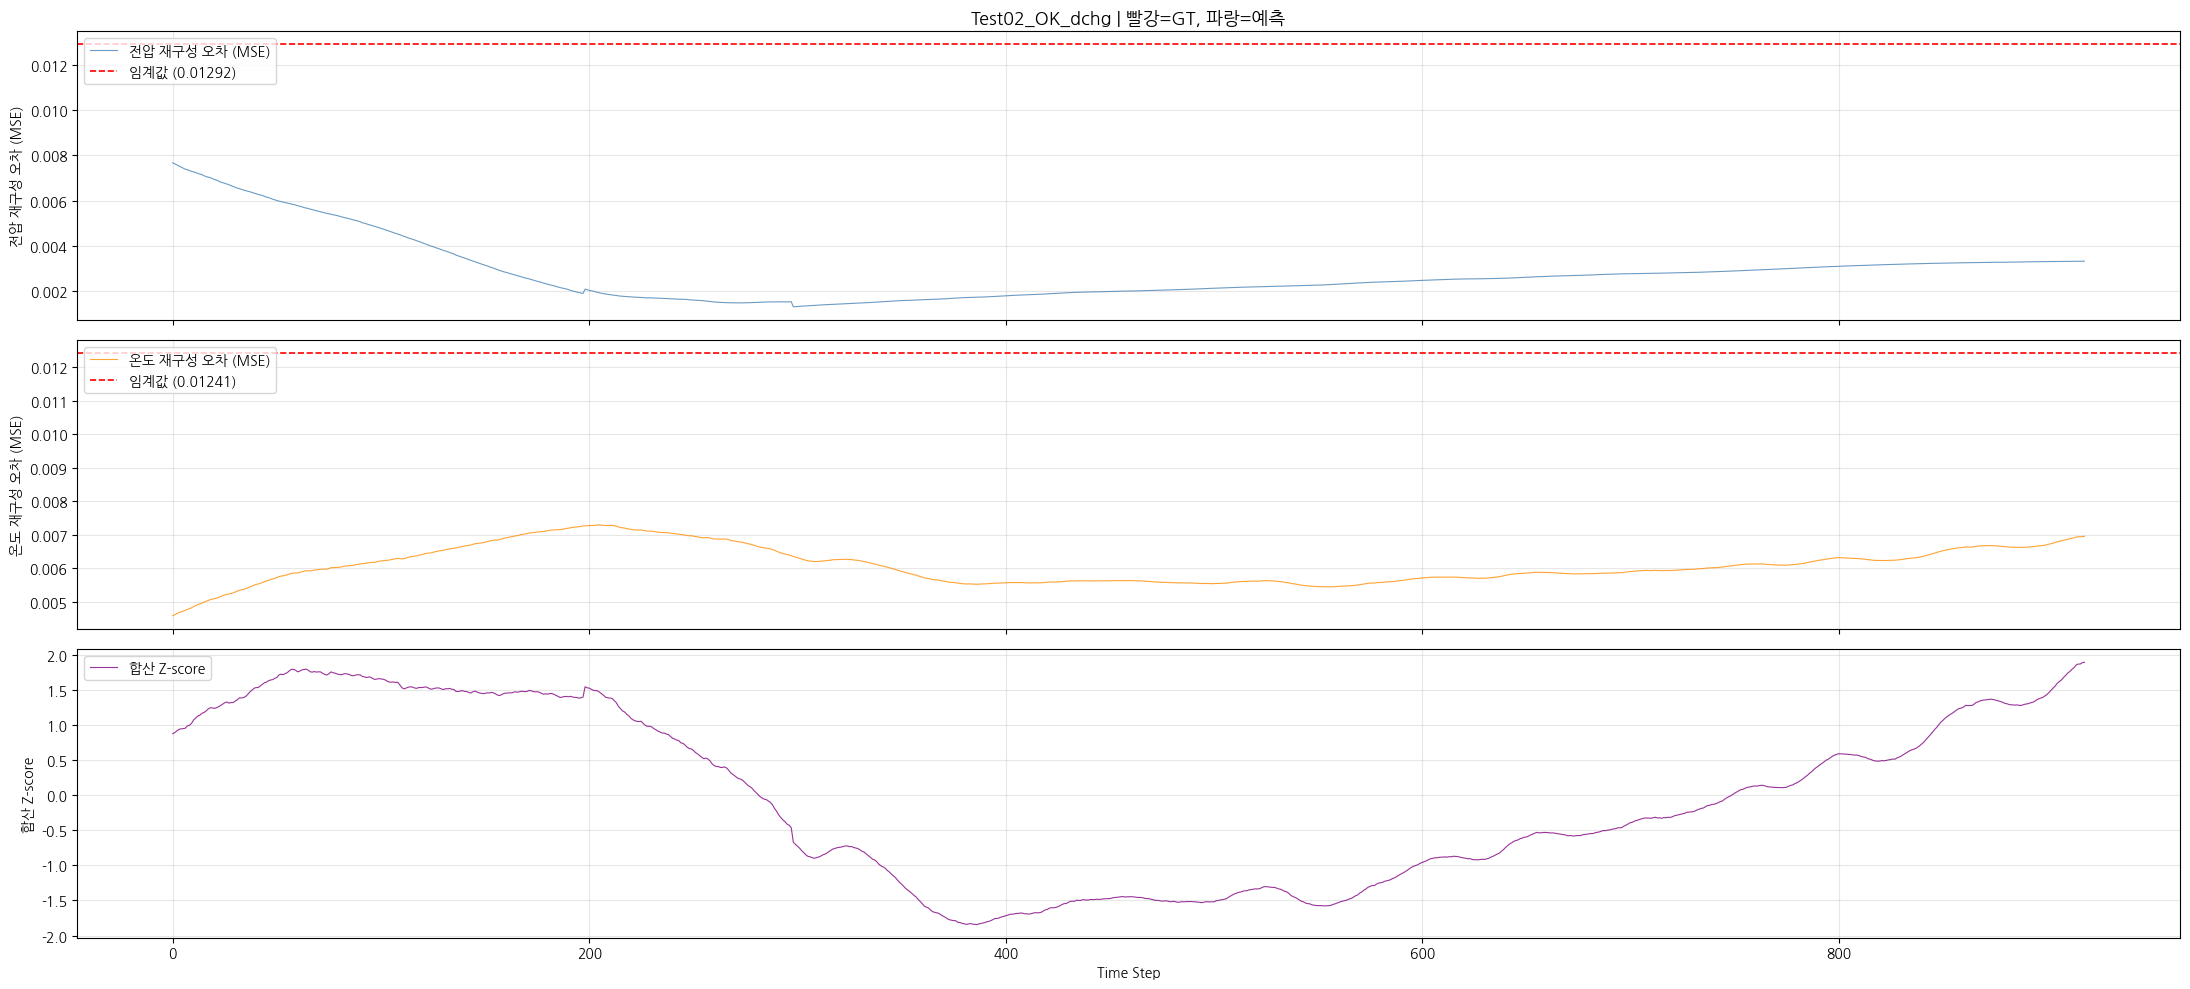

Test02_OK_dchg | GT=0행, 예측=0행



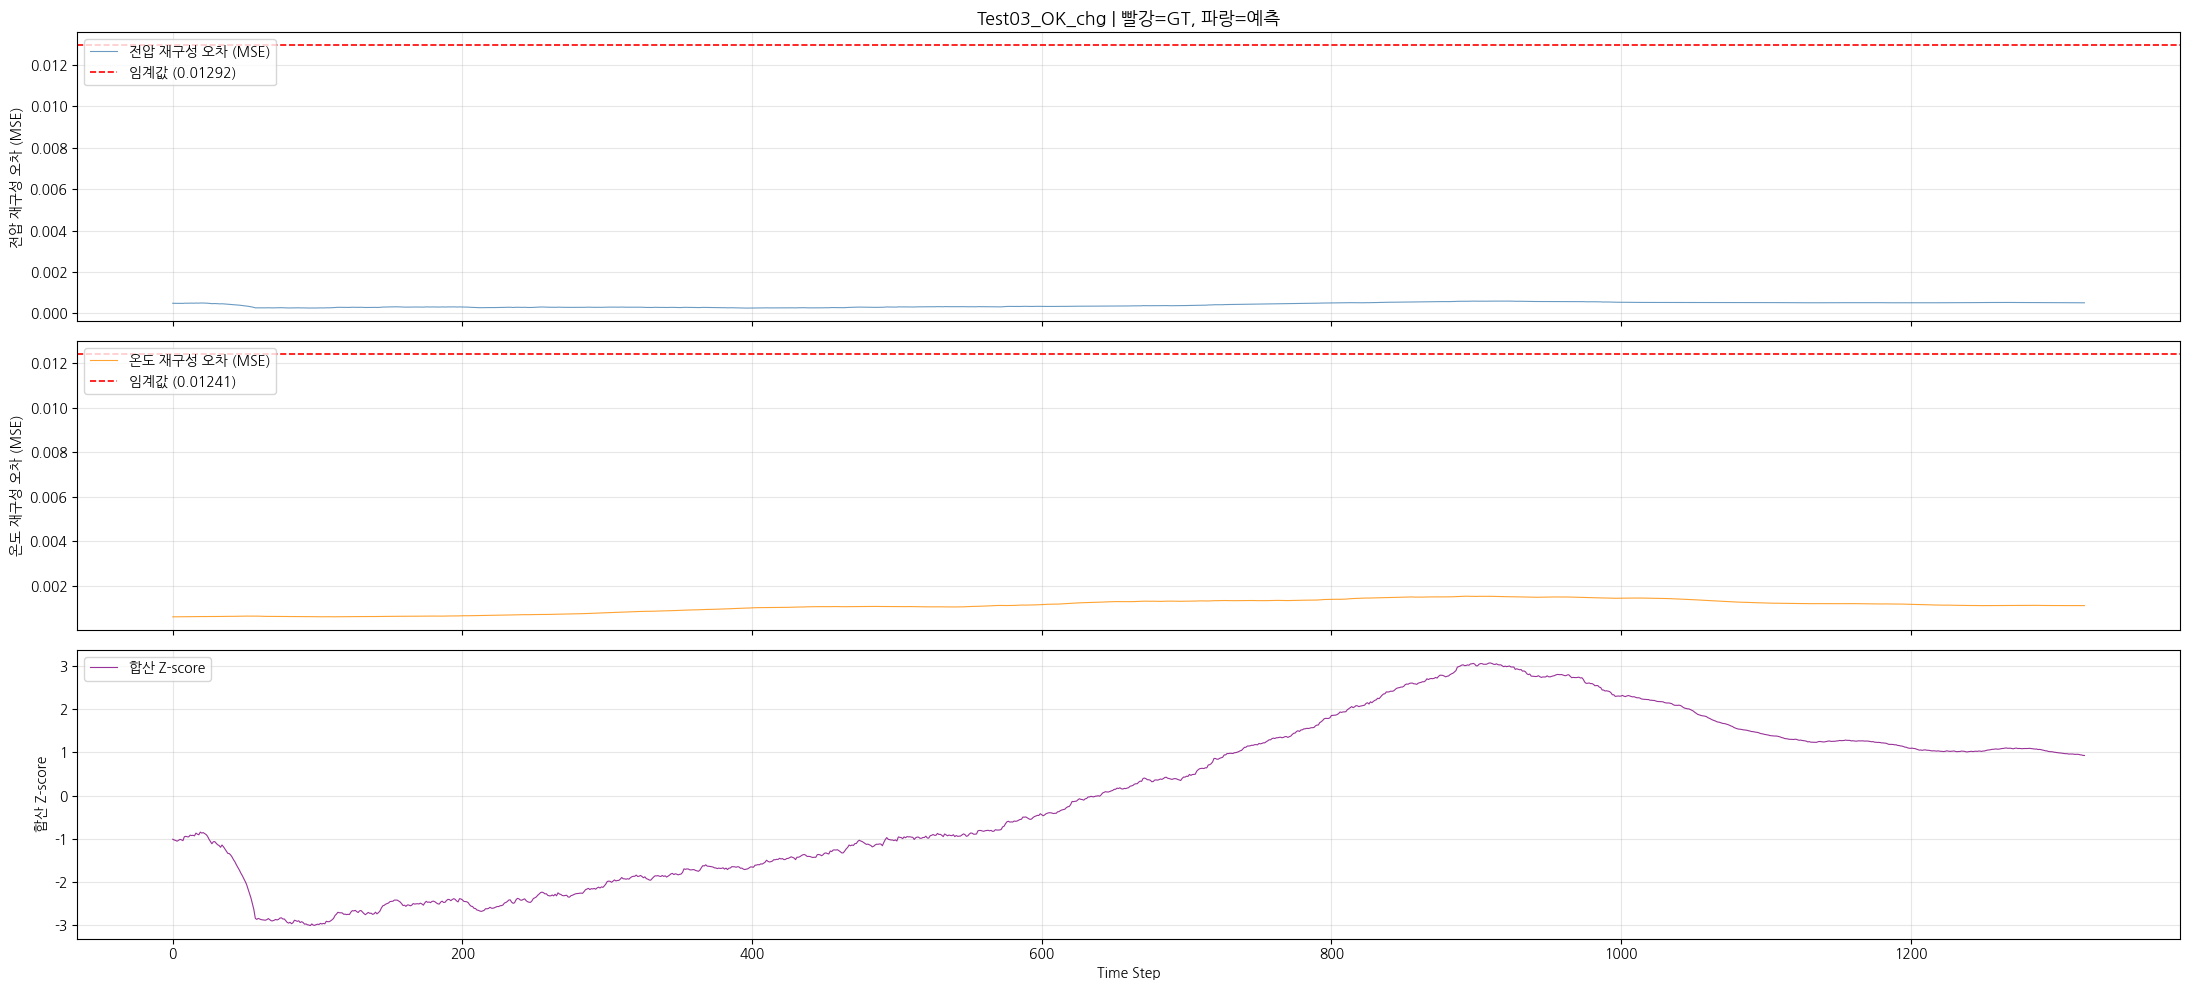

Test03_OK_chg | GT=0행, 예측=0행



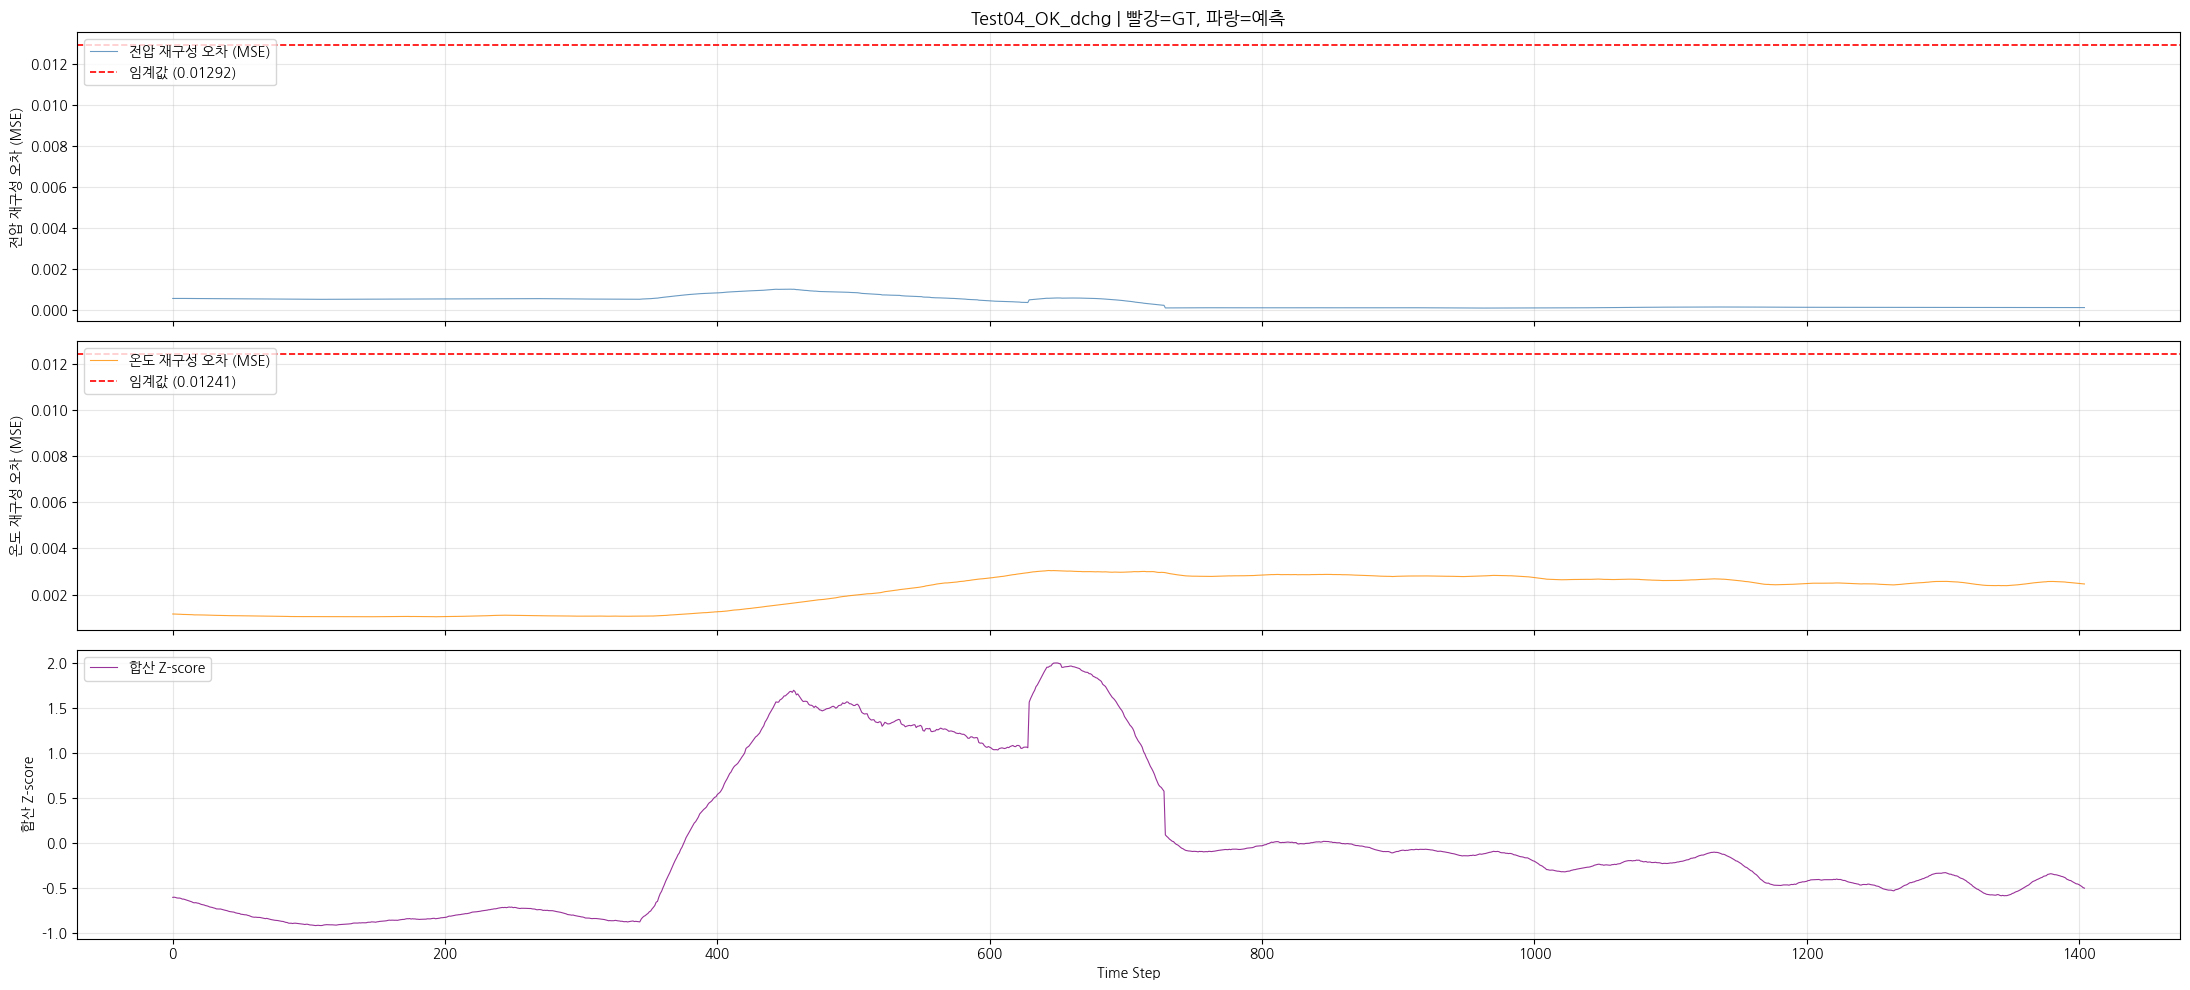

Test04_OK_dchg | GT=0행, 예측=0행



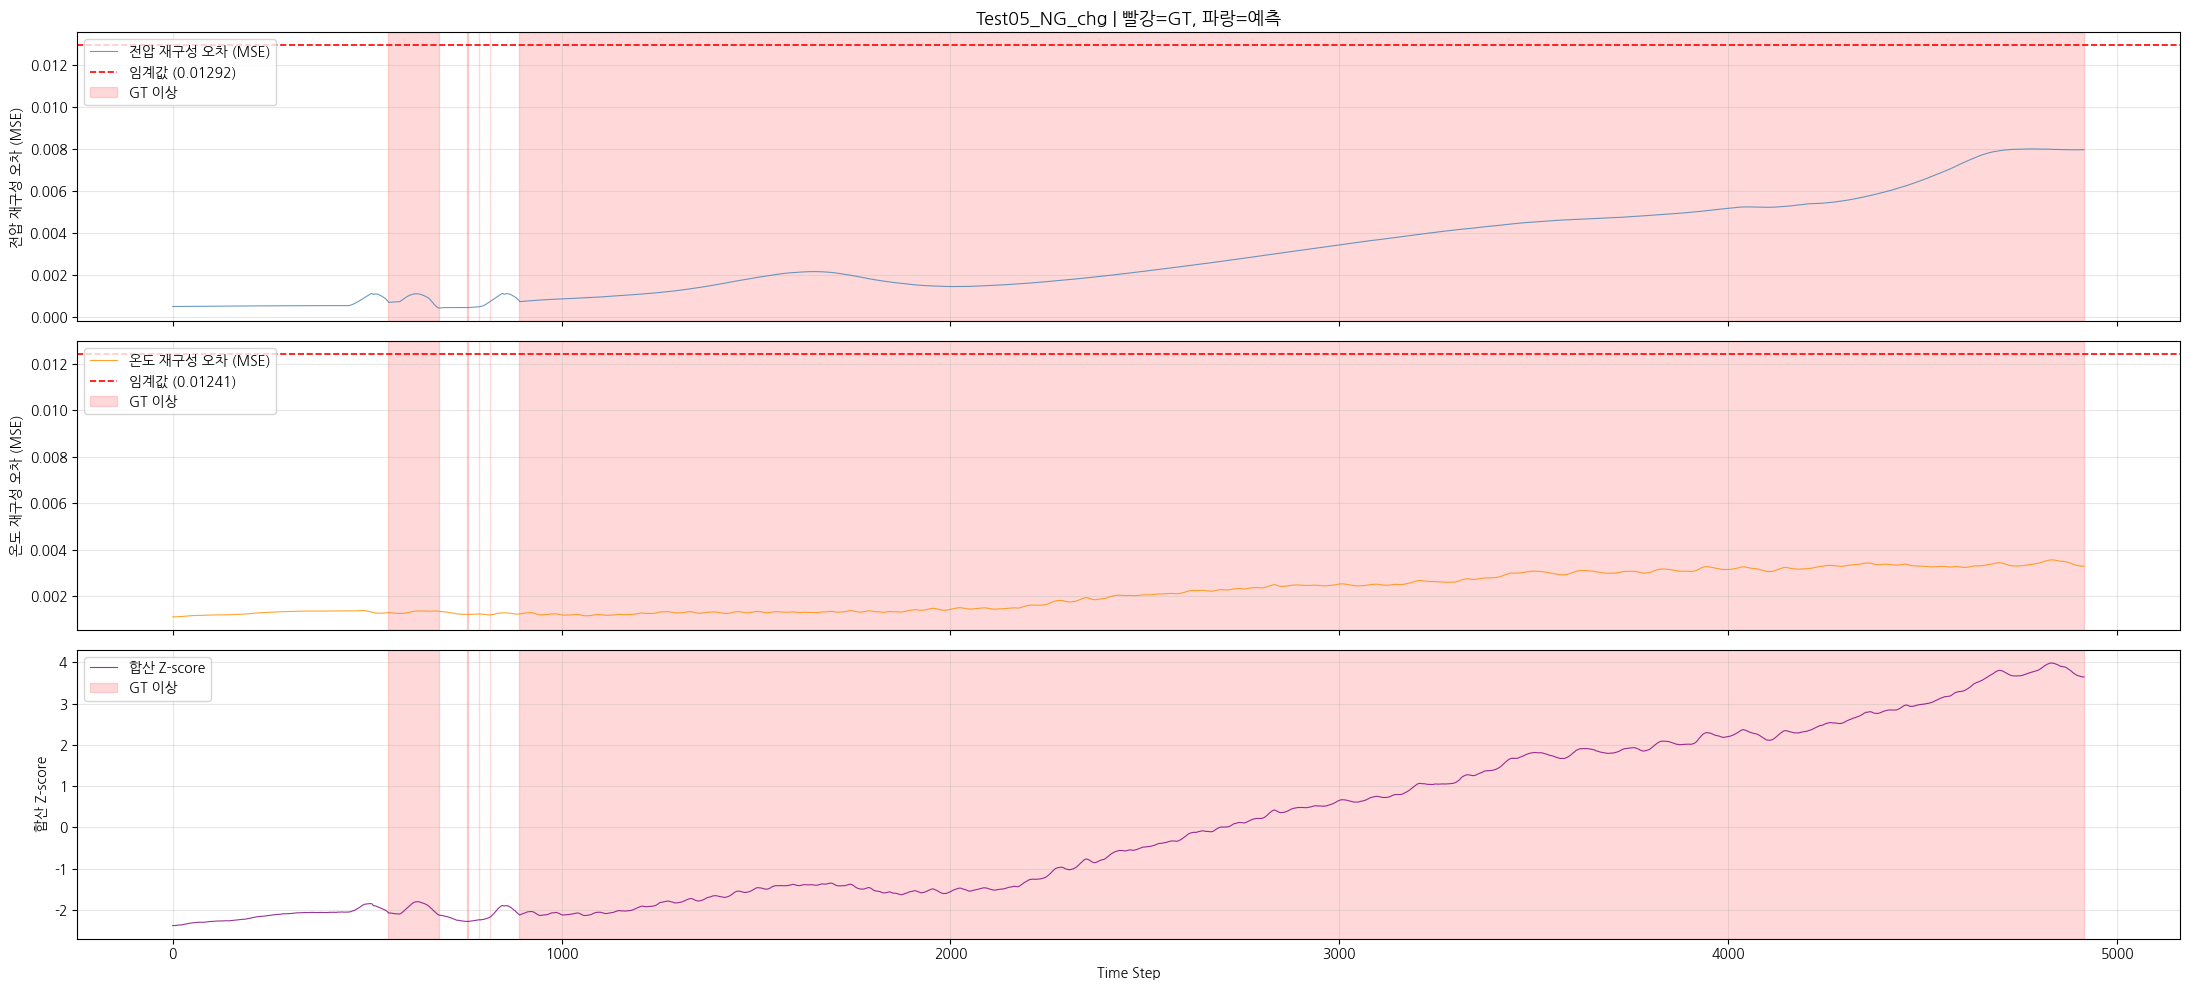

Test05_NG_chg | GT=4259행, 예측=0행



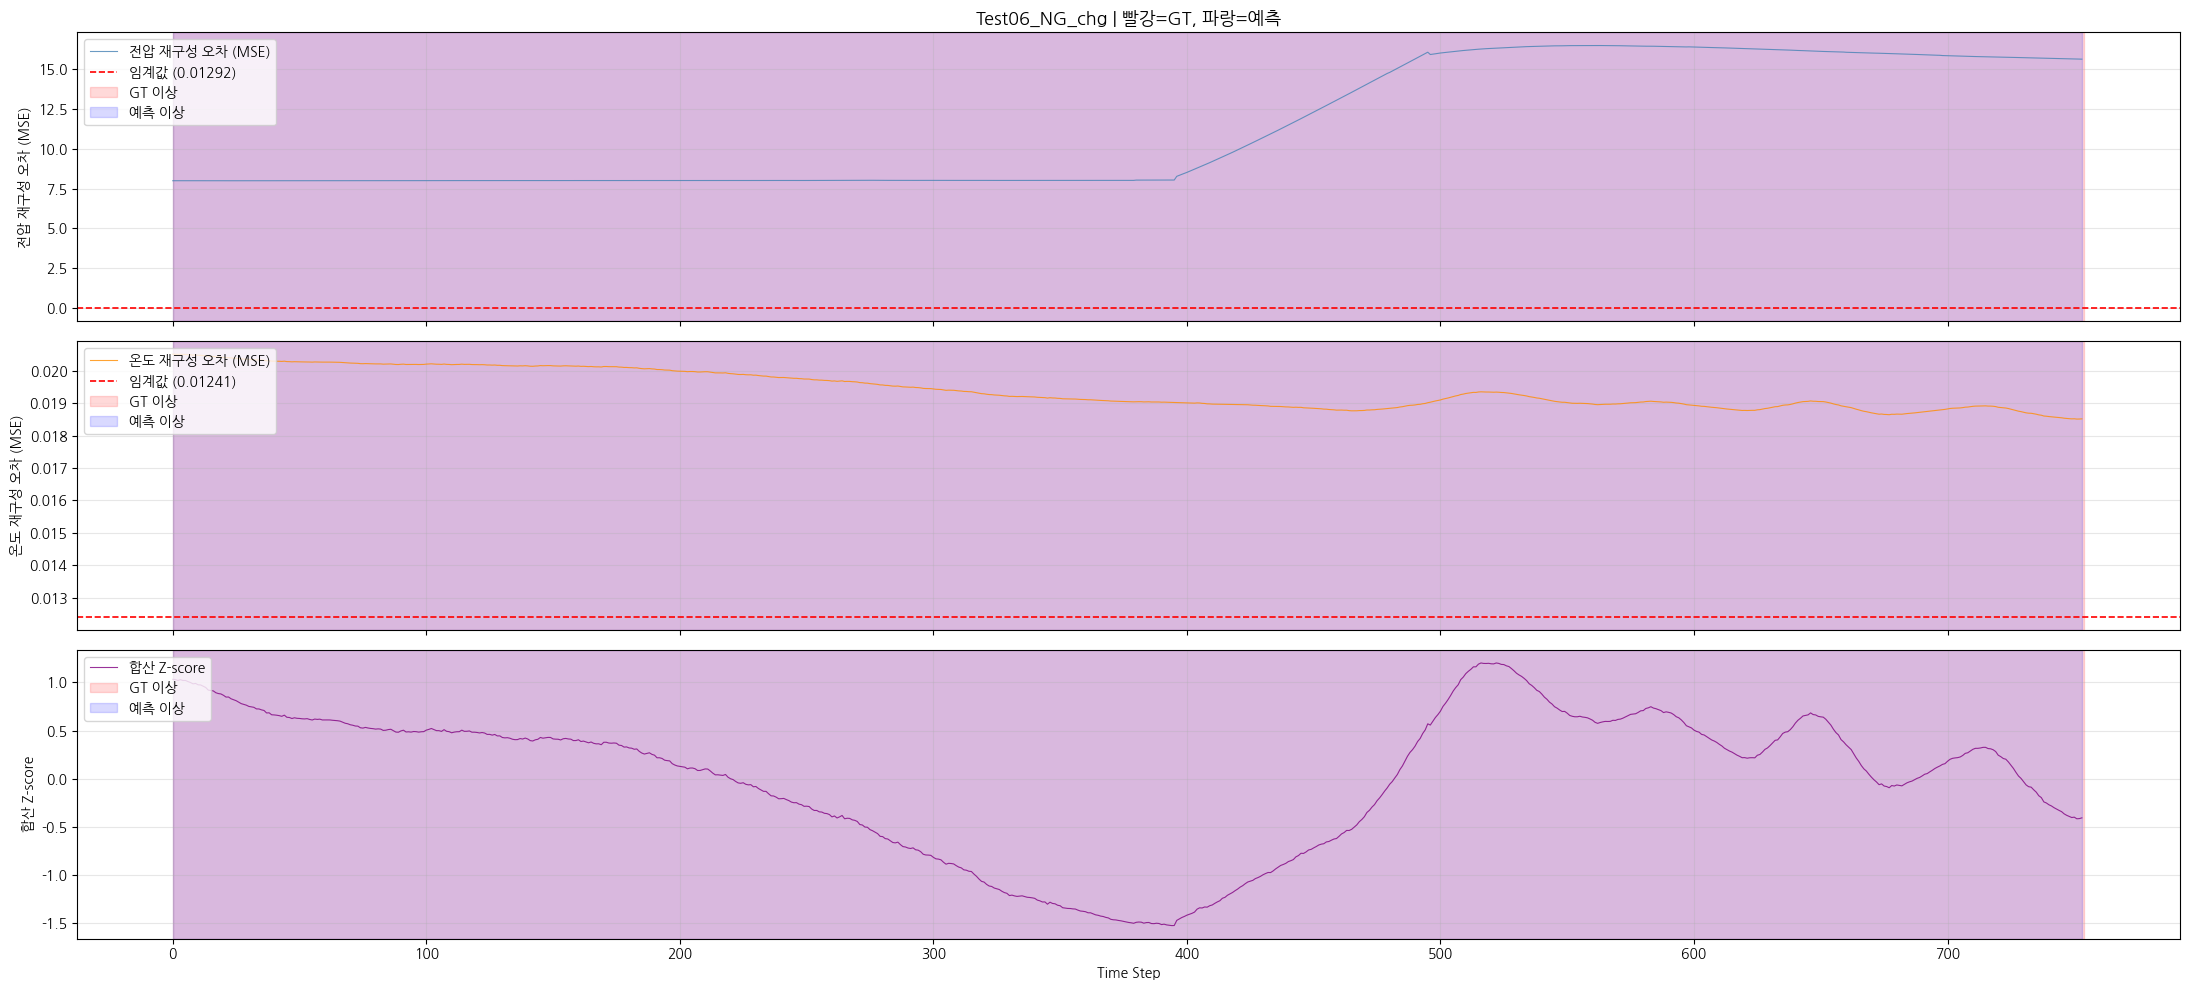

Test06_NG_chg | GT=854행, 예측=754행



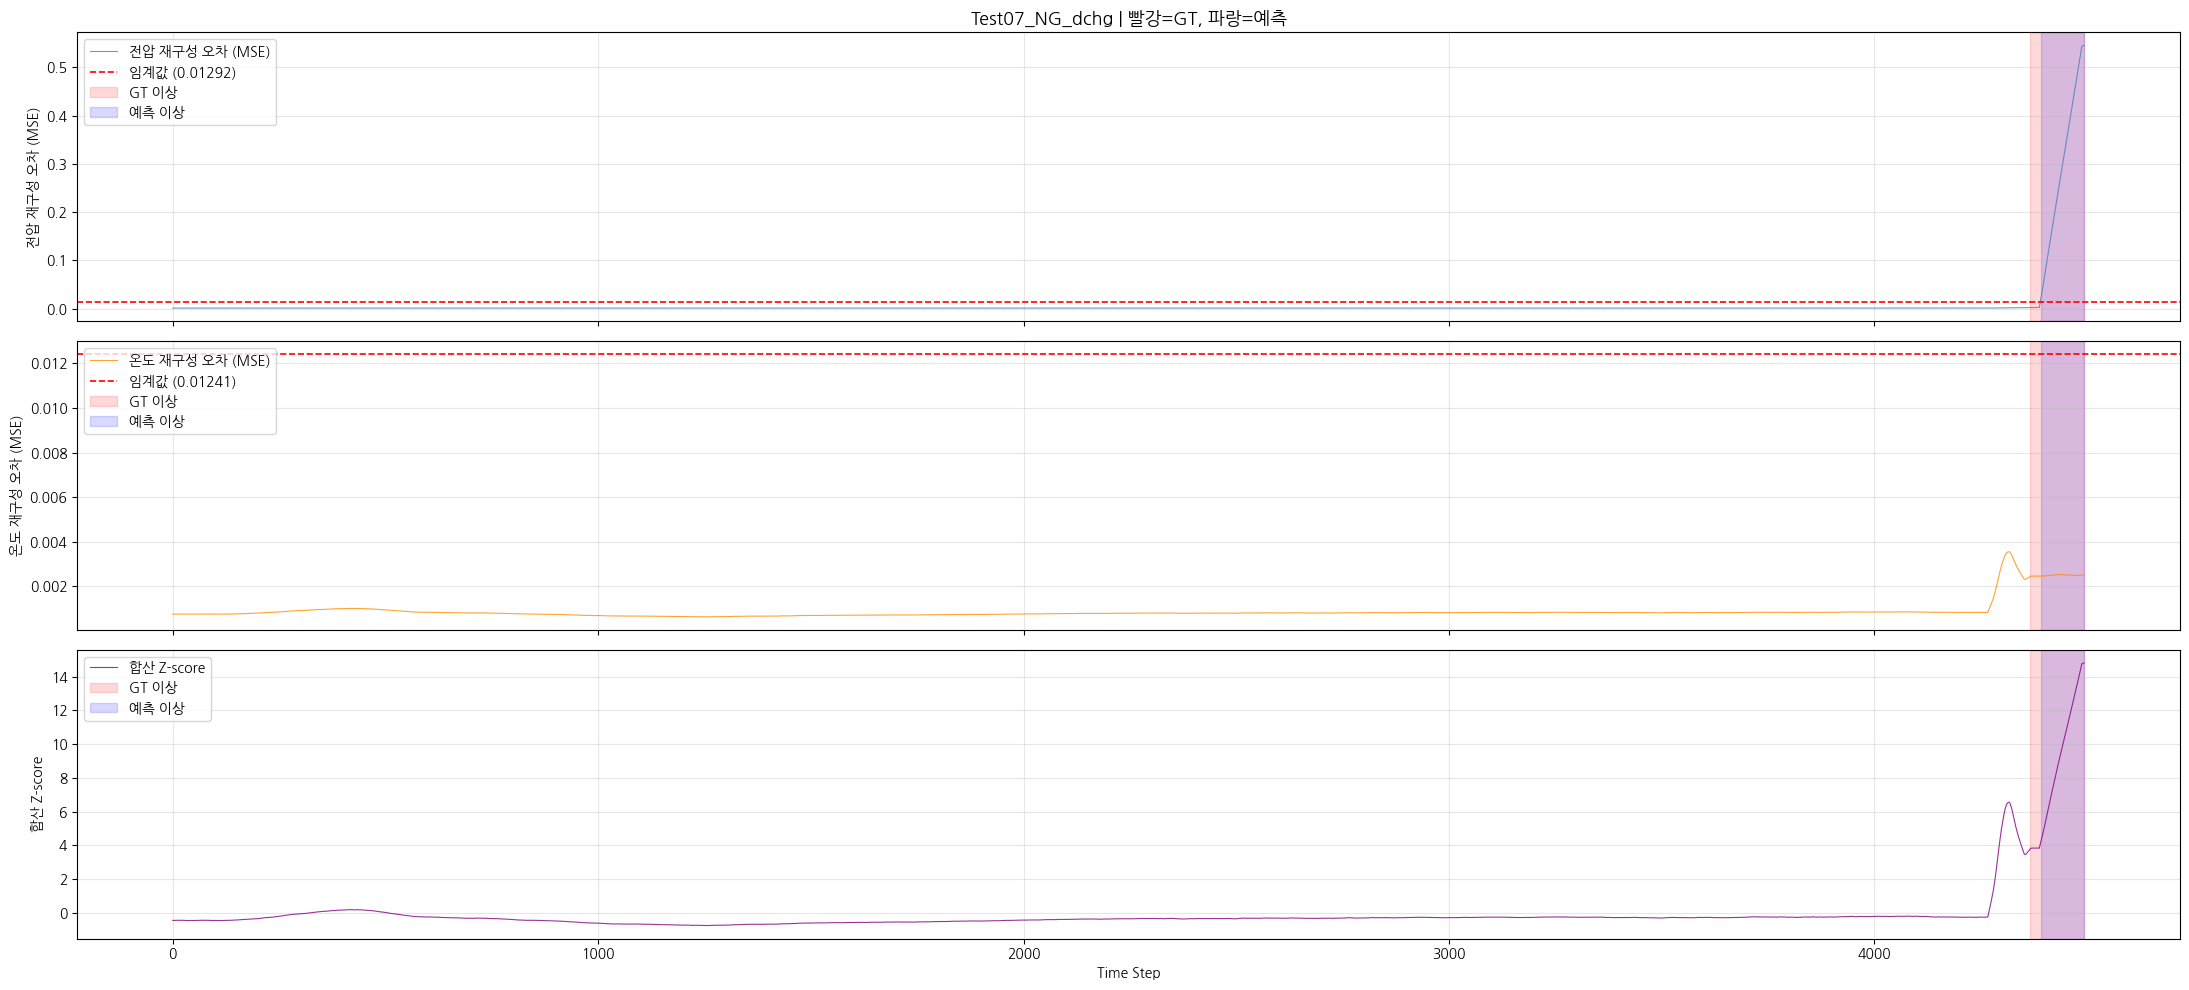

Test07_NG_dchg | GT=227행, 예측=103행



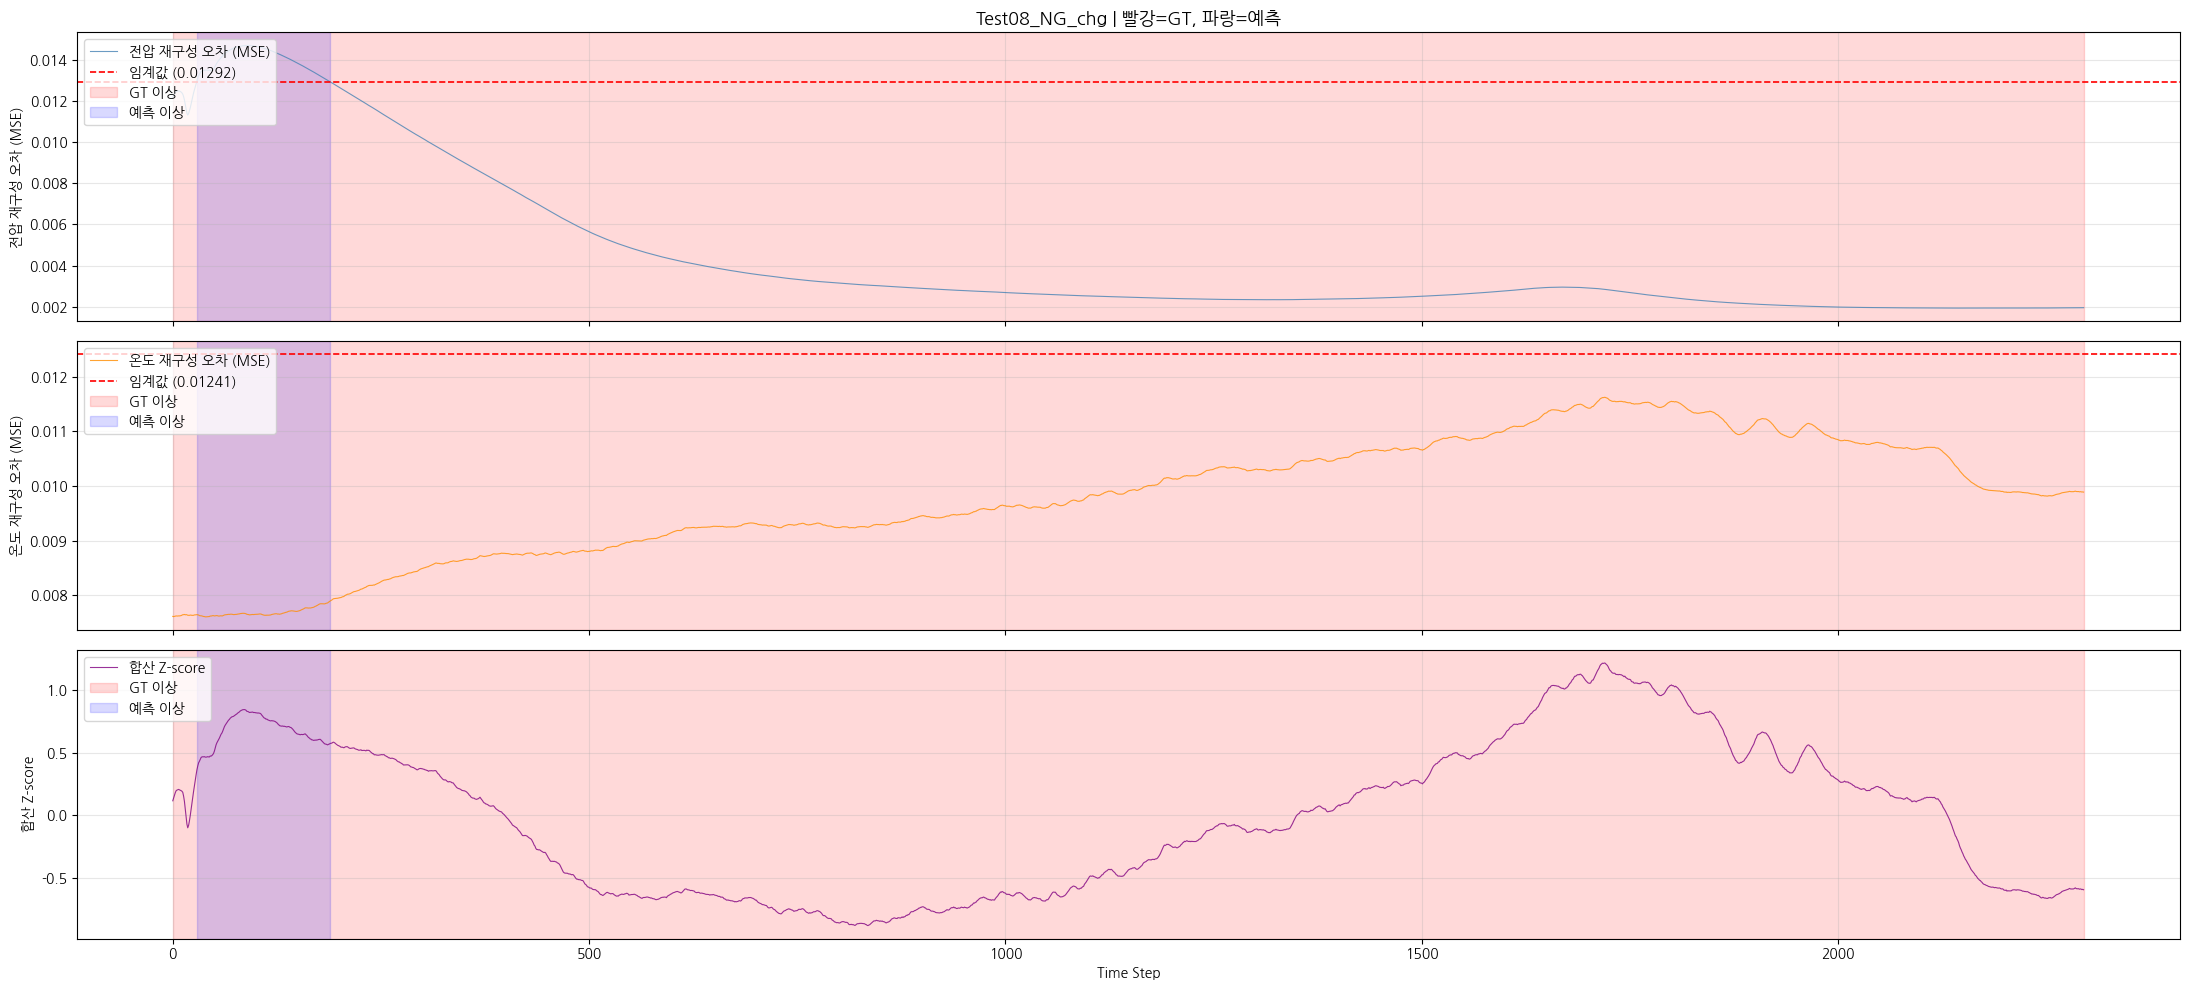

Test08_NG_chg | GT=2396행, 예측=161행



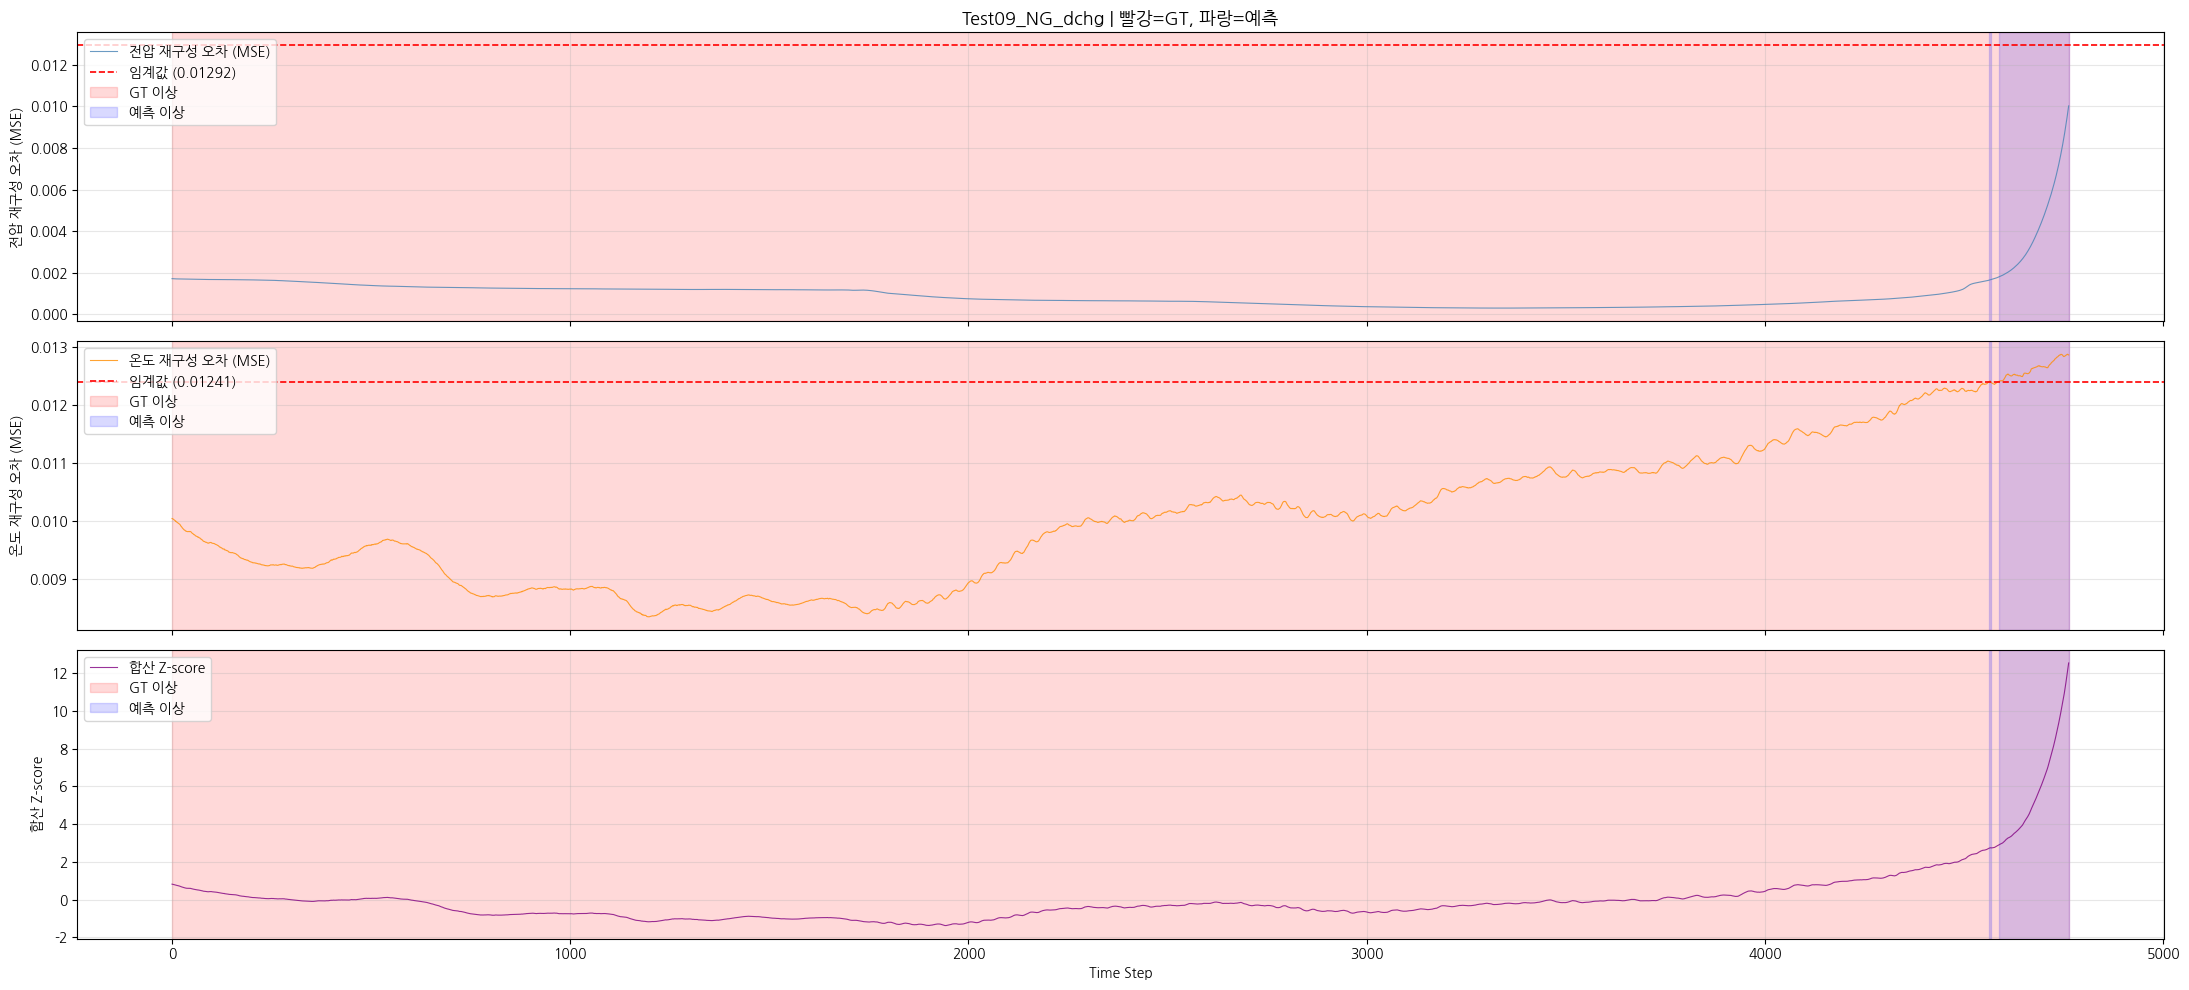

Test09_NG_dchg | GT=4864행, 예측=182행



In [99]:
# ── 결과 시각화 (전압/온도 오차 + 합산 점수) ──
for name, res in all_results.items():
    err_v    = res['err_volt']
    err_t    = res['err_temp']
    combined = res['combined']
    anomalies = res['anomalies']
    gt_label  = res['gt_label']

    if len(err_v) == 0:
        continue

    fig, axes = plt.subplots(3, 1, figsize=(22, 10), sharex=True)

    labels_data = [
        (err_v,    threshold_v, '전압 재구성 오차 (MSE)', 'steelblue'),
        (err_t,    threshold_t, '온도 재구성 오차 (MSE)', 'darkorange'),
        (combined, None,        '합산 Z-score',           'purple'),
    ]

    for ax, (data, thresh, title, color) in zip(axes, labels_data):
        ax.plot(data, color=color, linewidth=0.8, alpha=0.8, label=title)
        if thresh:
            ax.axhline(thresh, color='red', linestyle='--',
                       linewidth=1.2, label=f'임계값 ({thresh:.5f})')

        # GT 음영 (빨강)
        gt_len = min(len(gt_label), len(data))
        in_ng  = False
        for t in range(gt_len):
            if gt_label[t] == 1 and not in_ng:
                ng_start = t; in_ng = True
            elif gt_label[t] == 0 and in_ng:
                ax.axvspan(ng_start, t, color='red', alpha=0.15, label='GT 이상')
                in_ng = False
        if in_ng:
            ax.axvspan(ng_start, gt_len, color='red', alpha=0.15, label='GT 이상')

        # 예측 음영 (파랑)
        for s, e in anomalies:
            ax.axvspan(max(0, s), min(e, len(data)-1),
                       color='blue', alpha=0.15, label='예측 이상')

        handles, labels_leg = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels_leg, handles)).values(),
                  dict(zip(labels_leg, handles)).keys(), loc='upper left')
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)

    axes[0].set_title(f'{name} | 빨강=GT, 파랑=예측', fontsize=13)
    axes[2].set_xlabel('Time Step')
    plt.tight_layout()
    plt.show()

    ng_gt   = int(gt_label.sum())
    ng_pred = sum(e - s + 1 for s, e in anomalies)
    print(f"{name} | GT={ng_gt}행, 예측={ng_pred}행\n")

In [100]:
# ── 모델 저장 ──
model_volt.save(os.path.join(ckpt_dir, 'volt_autoencoder_final.keras'))
model_temp.save(os.path.join(ckpt_dir, 'temp_autoencoder_final.keras'))
print(f"전압 모델 저장 완료 → {ckpt_dir}/volt_autoencoder_final.keras")
print(f"온도 모델 저장 완료 → {ckpt_dir}/temp_autoencoder_final.keras")

# 나중에 불러올 때
# model_volt = tf.keras.models.load_model(os.path.join(ckpt_dir, 'volt_autoencoder_final.keras'))
# model_temp = tf.keras.models.load_model(os.path.join(ckpt_dir, 'temp_autoencoder_final.keras'))

전압 모델 저장 완료 → /mnt/c/Users/Administrator/github/project2/checkpoints_lstm/volt_autoencoder_final.keras
온도 모델 저장 완료 → /mnt/c/Users/Administrator/github/project2/checkpoints_lstm/temp_autoencoder_final.keras


- LSTM은 추세를 반영하는 모델이다보니 추세에 대해서만 반영하고 크기에 대해서는 고려되지 않는다. 따라서 크기에 대한 보강이 필요하다.
- 

# MAT-GEN 사용(파생변수만)